# Atividade prática — Preparação, limpeza, transformação e modelagem preditiva em dados industriais

## Tema do notebook

Neste notebook, você vai trabalhar com uma **base sintética inspirada em um problema industrial realista**: o monitoramento de uma linha de produção por sensores IoT.

A empresa coleta registros de operação de máquinas, forno, linha de produção e qualidade. A partir desses dados, a equipe deseja construir modelos para:

1. **Prever o consumo de energia do processo**, usando modelos de regressão.
2. **Prever se haverá falha operacional nas próximas 24 horas**, usando modelos de classificação.

O desafio é que a base foi construída com problemas comuns em projetos reais de dados industriais:

- datas em formatos diferentes;
- unidades misturadas;
- categorias inconsistentes;
- valores ausentes;
- valores fisicamente impossíveis;
- registros duplicados;
- variáveis redundantes;
- variáveis irrelevantes;
- outliers;
- atributos numéricos em formato textual;
- necessidade de transformação simbólico-numérica;
- necessidade de transformação numérica-numérica.

> **Importante:** este notebook é uma atividade. Ele não entrega a solução completa. Em várias células, você encontrará instruções e trechos iniciados de código para completar.

## Objetivos de aprendizagem

Ao final da atividade, você deverá ser capaz de:

1. diagnosticar problemas de qualidade em uma base de dados;
2. limpar inconsistências em variáveis numéricas, categóricas e temporais;
3. converter variáveis simbólicas em variáveis numéricas;
4. aplicar transformações numéricas, como padronização, normalização ou transformação logarítmica;
5. separar corretamente dados de treino e teste;
6. evitar vazamento de dados usando `Pipeline` e `ColumnTransformer`;
7. treinar e comparar modelos de regressão:
   - Ridge;
   - Lasso;
8. treinar e comparar modelos de classificação:
   - regressão logística;
   - árvore de decisão;
   - floresta aleatória;
9. avaliar os modelos com métricas adequadas;
10. interpretar resultados de forma crítica.

## Entregáveis da atividade

Ao final, entregue um notebook preenchido contendo:

1. análise inicial da base;
2. relatório das inconsistências encontradas;
3. justificativa das decisões de limpeza;
4. tabela com atributos antes e depois da limpeza;
5. transformações simbólico-numéricas aplicadas;
6. transformações numérica-numérica aplicadas;
7. comparação dos modelos de regressão;
8. comparação dos modelos de classificação;
9. gráficos e métricas;
10. conclusão final indicando quais modelos foram mais adequados e por quê.

# 1. Importação das bibliotecas

Nesta primeira etapa, vamos importar bibliotecas básicas para manipulação de dados, visualização e aprendizado de máquina.

Esta célula é fornecida pronta porque o foco da atividade não é a instalação ou importação das bibliotecas, mas sim o uso correto delas nas etapas seguintes.

In [2]:
!python -m pip install -r "C:\Users\will_\OneDrive\Documentos\GitHub\MLOPS_DATAPULSE\requirements.txt"

In [ ]:
# Bibliotecas básicas
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Separação dos dados
from sklearn.model_selection import train_test_split, cross_val_score

# Transformações e pré-processamento
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer

# Seleção e avaliação de modelos de regressão
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modelos de árvore e ensemble
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Métricas de classificação
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay,
    classification_report
)

# Configuração visual
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

# 2. Geração da base sintética industrial

A célula abaixo cria uma base sintética de monitoramento industrial.

O cenário é o seguinte:

Uma fábrica monitora linhas de produção por sensores IoT. Cada registro representa uma janela de operação de uma máquina em determinado momento. A base contém sensores do forno, pressão da linha, vibração, velocidade de esteira, umidade, setup, paradas não planejadas e informações categóricas de linha, turno e máquina.

A base também inclui dois alvos:

- `consumo_energia_kwh`: alvo de regressão;
- `falha_24h`: alvo de classificação.

A base foi propositalmente contaminada com problemas de qualidade. Portanto, **não use os dados diretamente para treinar modelos**.

In [5]:
# ------------------------------------------------------------
# Geração de uma base sintética industrial com inconsistências
# ------------------------------------------------------------

rng = np.random.default_rng(RANDOM_STATE)
n = 1200

# Variáveis estruturais limpas, usadas internamente para gerar os dados
datas = pd.date_range("2025-01-01 00:00:00", periods=n, freq="6h")

linha_limpa = rng.choice(["A", "B", "C"], size=n, p=[0.42, 0.34, 0.24])
turno_limpo = rng.choice(["manha", "tarde", "noite"], size=n, p=[0.34, 0.33, 0.33])
maquina_limpa = rng.choice([f"M{i:02d}" for i in range(1, 9)], size=n)

efeito_linha_temp = np.select(
    [linha_limpa == "A", linha_limpa == "B", linha_limpa == "C"],
    [0, 18, -12]
)

efeito_turno_temp = np.select(
    [turno_limpo == "manha", turno_limpo == "tarde", turno_limpo == "noite"],
    [-5, 8, 3]
)

idade_maquina_anos = rng.integers(1, 16, size=n)
temperatura_c_real = 760 + efeito_linha_temp + efeito_turno_temp + rng.normal(0, 18, size=n)
pressao_bar_real = 5.5 + 0.03 * (temperatura_c_real - 760) + rng.normal(0, 0.35, size=n)
vibracao_mm_s_real = 1.5 + 0.13 * idade_maquina_anos + rng.normal(0, 0.45, size=n)
velocidade_esteira_real = 42 + rng.normal(0, 4.5, size=n)
umidade_pct_real = np.clip(55 + rng.normal(0, 12, size=n), 18, 96)
tamanho_lote_real = rng.integers(800, 5000, size=n)
tempo_setup_min_real = np.clip(35 + 1.2 * idade_maquina_anos + rng.normal(0, 12, size=n), 5, 120)
paradas_nao_planejadas_real = rng.poisson(lam=np.clip(0.3 + 0.06 * idade_maquina_anos, 0.2, 2.0), size=n)

# Alvo de regressão: consumo de energia
consumo_energia_real = (
    210
    + 0.18 * temperatura_c_real
    + 5.8 * pressao_bar_real
    + 7.0 * vibracao_mm_s_real
    + 0.015 * tamanho_lote_real
    + 1.4 * tempo_setup_min_real
    + 14 * paradas_nao_planejadas_real
    + rng.normal(0, 22, size=n)
)

# Alvo auxiliar de qualidade
taxa_defeitos_pct_real = np.clip(
    1.5
    + 0.035 * np.abs(temperatura_c_real - 765)
    + 0.42 * np.maximum(vibracao_mm_s_real - 2.5, 0)
    + 0.12 * paradas_nao_planejadas_real
    + rng.normal(0, 0.7, size=n),
    0,
    18
)

# Alvo de classificação: falha operacional em até 24h
logit_falha = (
    -5.0
    + 0.020 * (temperatura_c_real - 760)
    + 0.55 * np.maximum(vibracao_mm_s_real - 2.2, 0)
    + 0.22 * paradas_nao_planejadas_real
    + 0.018 * tempo_setup_min_real
    + 0.065 * idade_maquina_anos
)

prob_falha = 1 / (1 + np.exp(-logit_falha))
falha_24h = rng.binomial(1, prob_falha, size=n)

# Formatos mistos de datas
formatos_data = ["%Y-%m-%d %H:%M:%S", "%d/%m/%Y %H:%M", "%m-%d-%Y %H:%M"]
data_registro = [
    dt.strftime(formatos_data[i % len(formatos_data)])
    for i, dt in enumerate(datas)
]

# Inconsistências categóricas
aliases_linha = {
    "A": ["Linha A", "linha a", "A", "L-A", "linha_A"],
    "B": ["Linha B", "linha b", "B", "L-B", "linha_B"],
    "C": ["Linha C", "linha c", "C", "L-C", "linha_C"],
}

aliases_turno = {
    "manha": ["Manhã", "MANHA", "manha", "Matutino", "M"],
    "tarde": ["Tarde", "TARDE", "tarde", "Vespertino", "T"],
    "noite": ["Noite", "NOITE", "noite", "Noturno", "N"],
}

linha_raw = [rng.choice(aliases_linha[x]) for x in linha_limpa]
turno_raw = [rng.choice(aliases_turno[x]) for x in turno_limpo]

# Mistura de unidades: Celsius/Fahrenheit e bar/psi
usa_fahrenheit = rng.random(n) < 0.18
temperatura_valor = np.where(
    usa_fahrenheit,
    temperatura_c_real * 9 / 5 + 32,
    temperatura_c_real
)
unidade_temperatura = np.where(usa_fahrenheit, "F", "C")

usa_psi = rng.random(n) < 0.22
pressao_valor = np.where(
    usa_psi,
    pressao_bar_real * 14.5038,
    pressao_bar_real
)
unidade_pressao = np.where(usa_psi, "psi", "bar")

# Montagem do DataFrame bruto
dados_raw = pd.DataFrame({
    "registro_id": [f"REG-{i:05d}" for i in range(n)],
    "data_registro": data_registro,
    "linha_producao": linha_raw,
    "turno": turno_raw,
    "maquina": maquina_limpa,
    "idade_maquina_anos": idade_maquina_anos,
    "temperatura_valor": np.round(temperatura_valor, 2),
    "unidade_temperatura": unidade_temperatura,
    "pressao_valor": np.round(pressao_valor, 3),
    "unidade_pressao": unidade_pressao,
    "vibracao_motor_mm_s": np.round(vibracao_mm_s_real, 3),
    "velocidade_esteira_m_min": np.round(velocidade_esteira_real, 2),
    "umidade_pct": np.round(umidade_pct_real, 2),
    "tamanho_lote": tamanho_lote_real,
    "tempo_setup_min": np.round(tempo_setup_min_real, 2),
    "paradas_nao_planejadas": paradas_nao_planejadas_real,
    "taxa_defeitos_pct": np.round(taxa_defeitos_pct_real, 3),
    "energia_sensor_b_kwh": np.round(consumo_energia_real * 1.015 + rng.normal(0, 8, size=n), 2),
    "codigo_campanha": rng.choice(["A12", "B07", "C99", "X00"], size=n),
    "ruido_aleatorio": rng.normal(0, 1, size=n),
    "consumo_energia_kwh": np.round(consumo_energia_real, 2),
    "falha_24h": falha_24h
})

# Converter colunas selecionadas para object antes de inserir textos com vírgula decimal
dados_raw["consumo_energia_kwh"] = dados_raw["consumo_energia_kwh"].astype(object)
dados_raw["vibracao_motor_mm_s"] = dados_raw["vibracao_motor_mm_s"].astype(object)

# Transformar parte dos números em textos com vírgula decimal
idx_consumo_texto = rng.choice(dados_raw.index, size=80, replace=False)
dados_raw.loc[idx_consumo_texto, "consumo_energia_kwh"] = (
    dados_raw.loc[idx_consumo_texto, "consumo_energia_kwh"]
    .map(lambda x: f"{float(x):.2f}".replace(".", ","))
)

idx_vibracao_texto = rng.choice(dados_raw.index, size=55, replace=False)
dados_raw.loc[idx_vibracao_texto, "vibracao_motor_mm_s"] = (
    dados_raw.loc[idx_vibracao_texto, "vibracao_motor_mm_s"]
    .map(lambda x: f"{float(x):.3f}".replace(".", ","))
)

# Inserir categorias inválidas
idx_cat = rng.choice(dados_raw.index, size=30, replace=False)
dados_raw.loc[idx_cat[:10], "linha_producao"] = "?"
dados_raw.loc[idx_cat[10:20], "turno"] = "sem_info"
dados_raw.loc[idx_cat[20:], "maquina"] = "M-erro"

# Inserir valores ausentes
cols_missing = [
    "temperatura_valor", "pressao_valor", "vibracao_motor_mm_s",
    "velocidade_esteira_m_min", "umidade_pct", "turno", "linha_producao"
]
for col in cols_missing:
    idx_nan = rng.choice(dados_raw.index, size=int(0.035 * n), replace=False)
    dados_raw.loc[idx_nan, col] = np.nan

# Inserir valores fisicamente impossíveis
idx_bad = rng.choice(dados_raw.index, size=32, replace=False)
dados_raw.loc[idx_bad[:6], "temperatura_valor"] = -50
dados_raw.loc[idx_bad[6:12], "pressao_valor"] = -3
dados_raw.loc[idx_bad[12:18], "vibracao_motor_mm_s"] = -1
dados_raw.loc[idx_bad[18:24], "umidade_pct"] = 140
dados_raw.loc[idx_bad[24:28], "velocidade_esteira_m_min"] = -20
dados_raw.loc[idx_bad[28:], "tamanho_lote"] = 0

# Inserir outliers extremos plausíveis ou suspeitos
idx_out = rng.choice(dados_raw.index, size=18, replace=False)
dados_raw.loc[idx_out[:6], "consumo_energia_kwh"] = (
    pd.to_numeric(
        dados_raw.loc[idx_out[:6], "consumo_energia_kwh"].astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    ) * 2.7
)
dados_raw.loc[idx_out[6:12], "vibracao_motor_mm_s"] = 12 + rng.normal(0, 1, size=6)
dados_raw.loc[idx_out[12:], "tempo_setup_min"] = 240 + rng.normal(0, 10, size=6)

# Inserir alguns registros duplicados
duplicatas = dados_raw.sample(35, random_state=RANDOM_STATE)
dados_raw = pd.concat([dados_raw, duplicatas], ignore_index=True)

print("Dimensão da base bruta:", dados_raw.shape)
display(dados_raw.head(10))

Dimensão da base bruta: (1235, 22)


,registro_id,data_registro,linha_producao,turno,maquina,idade_maquina_anos,temperatura_valor,unidade_temperatura,pressao_valor,unidade_pressao,vibracao_motor_mm_s,velocidade_esteira_m_min,umidade_pct,tamanho_lote,tempo_setup_min,paradas_nao_planejadas,taxa_defeitos_pct,energia_sensor_b_kwh,codigo_campanha,ruido_aleatorio,consumo_energia_kwh,falha_24h
0,REG-00000,2025-01-01 00:00:00,L-C,Tarde,M05,10,764.04,C,5.925,bar,2.826,42.87,60.76,1958,34.68,3,2.044,550.54,C99,-1.069120,540.04,1
1,REG-00001,01/01/2025 06:00,Linha B,tarde,M05,13,784.92,C,88.796,psi,3.252,36.85,25.79,3569,48.07,2,2.443,584.19,X00,0.257096,576.34,0
2,REG-00002,01-01-2025 12:00,Linha C,N,M02,10,751.23,C,5.337,bar,3.003,40.38,79.18,2014,26.37,0,2.150,484.30,X00,-1.518390,477.44,0
3,REG-00003,2025-01-01 18:00:00,linha b,noite,M07,9,792.82,C,6.539,bar,"2,538",35.66,61.34,2943,49.33,0,1.956,541.60,X00,-0.094083,521.25,0
4,REG-00004,02/01/2025 00:00,linha_A,M,M06,8,1367.43,F,57.961,psi,2.431,44.73,63.36,2728,21.74,1,2.022,443.83,B07,1.095612,443.24,0
5,REG-00005,01-02-2025 06:00,linha c,manha,M07,4,743.73,C,4.695,bar,2.788,42.75,53.28,2411,41.74,0,1.938,497.17,C99,0.547554,483.53,0
6,REG-00006,2025-01-02 12:00:00,Linha C,TARDE,M04,5,750.38,C,5.194,bar,3.37,34.59,32.74,1329,24.78,1,1.989,480.89,A12,-1.233950,471.29,0
7,REG-00007,02/01/2025 18:00,C,T,M08,12,727.46,C,4.399,bar,2.518,43.58,63.10,3220,44.82,1,3.672,468.02,C99,-1.898386,467.86,0
8,REG-00008,01-03-2025 00:00,L-A,manha,M04,2,738.43,C,4.939,bar,1.193,41.75,48.22,4958,44.65,2,3.209,548.14,C99,0.496945,548.53,0
9,REG-00009,2025-01-03 06:00:00,B,Tarde,M07,2,-50.00,C,7.522,bar,1.329,44.32,61.53,3502,65.05,0,2.570,545.62,X00,1.581199,550.96,0


# 3. Dicionário de dados

Use este dicionário como referência para interpretar as variáveis.

| Variável | Descrição | Observação |
|---|---|---|
| `registro_id` | Identificador do registro | Pode conter duplicatas após a contaminação |
| `data_registro` | Data e hora da medição | Está em formatos mistos |
| `linha_producao` | Linha de produção | Contém categorias inconsistentes |
| `turno` | Turno de operação | Contém categorias inconsistentes |
| `maquina` | Código da máquina | Pode conter categoria inválida |
| `idade_maquina_anos` | Idade da máquina em anos | Numérica |
| `temperatura_valor` | Temperatura medida | Mistura Celsius e Fahrenheit |
| `unidade_temperatura` | Unidade da temperatura | `C` ou `F` |
| `pressao_valor` | Pressão medida | Mistura bar e psi |
| `unidade_pressao` | Unidade da pressão | `bar` ou `psi` |
| `vibracao_motor_mm_s` | Vibração do motor | Pode estar como texto com vírgula decimal |
| `velocidade_esteira_m_min` | Velocidade da esteira | Pode conter valores impossíveis |
| `umidade_pct` | Umidade percentual | Pode conter valores maiores que 100 |
| `tamanho_lote` | Tamanho do lote | Pode conter valores inválidos |
| `tempo_setup_min` | Tempo de setup | Pode conter outliers |
| `paradas_nao_planejadas` | Número de paradas não planejadas | Numérica discreta |
| `taxa_defeitos_pct` | Taxa de defeitos do processo | Pode ajudar na previsão |
| `energia_sensor_b_kwh` | Medição alternativa de energia | Variável redundante em relação ao consumo |
| `codigo_campanha` | Código sem relação com o processo | Variável irrelevante proposital |
| `ruido_aleatorio` | Ruído aleatório | Variável irrelevante proposital |
| `consumo_energia_kwh` | Consumo de energia | Alvo de regressão |
| `falha_24h` | Indica falha nas próximas 24 horas | Alvo de classificação |

# 4. Atividade 1 — Diagnóstico inicial da base

Antes de limpar a base, faça uma análise exploratória inicial.

Você deve responder:

1. Quantas linhas e colunas existem?
2. Quais colunas são numéricas?
3. Quais colunas são categóricas?
4. Quais colunas têm valores ausentes?
5. Há registros duplicados?
6. Há variáveis com tipos inadequados?
7. Há variáveis que deveriam ser numéricas, mas aparecem como `object`?
8. Há categorias inconsistentes?
9. Há valores fisicamente impossíveis?
10. Há outliers evidentes?

Complete a célula seguinte com os comandos necessários.

In [6]:
# ------------------------------------------------------------
# Atividade 1 — Diagnóstico inicial
# ------------------------------------------------------------

dados = dados_raw.copy()

# TODO 1: mostrar dimensões da base
# Exemplo parcial:
print(f"\n{'='*80}")
print("---------Linhas e Colunas-------------")
print(f"{'='*80}")
print("Dimensão:", dados.shape)

# TODO 2: usar .info() para verificar tipos de dados
print(f"\n{'='*80}")
print("---------Tipagem das Variaveis-------------")
print(f"{'='*80}")
dados.info()
# Considerando as informações de tipagem e analisando uma amostra manualmente temos os tipos de varivaveis
vars_cat = ["registro_id", "linha_producao", "turno", "maquina",
            "unidade_temperatura", "unidade_pressao", "codigo_campanha", "falha_24h"]
vars_num = ["idade_maquina_anos", "temperatura_valor", "pressao_valor",
            "vibracao_motor_mm_s", "velocidade_esteira_m_min", "umidade_pct",
            "tamanho_lote", "tempo_setup_min", "paradas_nao_planejadas",
            "taxa_defeitos_pct", "energia_sensor_b_kwh", "ruido_aleatorio", "consumo_energia_kwh"]
vars_temp = ["data_registro"]
print("Variáveis Categóricas: ", vars_cat)
print("Variáveis Numéricas: ", vars_num)
print("Variáveis Temporais: ", vars_temp)
print("Tipagem incompativel: data_registro, vibracao_motor_mm_s, consumo_energia_kwh")


# TODO 3: calcular percentual de valores ausentes por coluna
percentual_ausente = dados.isnull().mean() * 100

# Ordenar do maior para o menor
percentual_ausente = percentual_ausente.sort_values(ascending=False)
print(f"\n{'='*80}")
print("---------Valores Ausentes-------------")
print(f"{'='*80}")
print(percentual_ausente)



# TODO 4: verificar duplicatas
n_duplicatas  = dados.duplicated().sum()
print(f"\n{'='*80}")
print("---------Registros Duplicados-------------")
print(f"{'='*80}")
print("Linhas idênticas: ", n_duplicatas)
n_duplicatas  = dados['registro_id'].duplicated().sum()
print("ID repetipo: ", n_duplicatas)



# TODO 6: verificar categorias únicas nas variáveis categóricas
print(f"\n{'='*80}")
print("---------Categorias inconsistentes-------------")
print(f"{'='*80}")
for col in vars_cat:
    if col not in ["registro_id"] :
      print(f"Variável: {col}")

      valores = sorted(dados[col].dropna().unique())

      print(f"Quantidade de valores distintos: {len(valores)}")
      print(valores)
      print(f"\n{"-"*10}")

print("Variaveis inconsistêntes: linha_producao, turno")

print(f"\n{'='*80}")
print("---------Valores fisicamente impossíveis-------------")
print(f"{'='*80}")
print("Resolvido na Atividade 4")

print(f"\n{'='*80}")
print("---------Outliers-------------")
print(f"{'='*80}")
dados["vibracao_motor_mm_s"] = pd.to_numeric(
    dados["vibracao_motor_mm_s"],
    errors="coerce"
).astype(float)


dados["consumo_energia_kwh"] = pd.to_numeric(
    dados["consumo_energia_kwh"],
    errors="coerce"
).astype(float)

for col in vars_num:

    Q1 = dados[col].quantile(0.25)
    Q3 = dados[col].quantile(0.75)

    IQR = Q3 - Q1

    LI = Q1 - 1.5 * IQR
    LS = Q3 + 1.5 * IQR

    qtd = (
        (dados[col] < LI) |
        (dados[col] > LS)
    ).sum()

    print(f"{col:30s} -> {qtd} outliers")



---------Linhas e Colunas-------------
Dimensão: (1235, 22)

---------Tipagem das Variaveis-------------
<class 'pandas.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   registro_id               1235 non-null   str    
 1   data_registro             1235 non-null   str    
 2   linha_producao            1192 non-null   str    
 3   turno                     1192 non-null   str    
 4   maquina                   1235 non-null   str    
 5   idade_maquina_anos        1235 non-null   int64  
 6   temperatura_valor         1193 non-null   float64
 7   unidade_temperatura       1235 non-null   str    
 8   pressao_valor             1190 non-null   float64
 9   unidade_pressao           1235 non-null   str    
 10  vibracao_motor_mm_s       1192 non-null   object 
 11  velocidade_esteira_m_min  1190 non-null   float64
 12  umidade_pct            

# 5. Atividade 2 — Padronização de datas, tipos numéricos e unidades

Nesta etapa, você deve transformar a base para que ela tenha tipos coerentes.

Tarefas:

1. Converter `data_registro` para o tipo `datetime`.
2. Converter `consumo_energia_kwh` para número, tratando vírgula decimal.
3. Converter `vibracao_motor_mm_s` para número, tratando vírgula decimal.
4. Converter temperatura para uma única unidade, preferencialmente Celsius.
5. Converter pressão para uma única unidade, preferencialmente bar.
6. Criar novas colunas padronizadas:
   - `temperatura_c`;
   - `pressao_bar`.
7. Decidir se as colunas originais de valor e unidade devem ser removidas depois da conversão.

A célula abaixo contém apenas um início de solução.

In [7]:
# ------------------------------------------------------------
# Atividade 2 — Conversão de tipos e unidades
# ------------------------------------------------------------

dados_limpos = dados.copy()

print(f"\n{'='*80}")
print("---------Correção da tipagem-------------")
print(f"{'='*80}")

dados_limpos["vibracao_motor_mm_s"] = pd.to_numeric(
    dados_limpos["vibracao_motor_mm_s"],
    errors="coerce"
).astype(float)


dados_limpos["consumo_energia_kwh"] = pd.to_numeric(
    dados_limpos["consumo_energia_kwh"],
    errors="coerce"
).astype(float)



from datetime import datetime

def padronizar_data(x):

    if pd.isna(x):
        return None

    x = str(x).strip()

    formatos = [
        "%Y/%m/%d %H:%M:%S",
        "%d/%m/%Y %H:%M",
        "%d-%m-%Y %H:%M",
        "%m-%d-%Y %H:%M",
        "%Y-%m-%d %H:%M:%S"
    ]

    for fmt in formatos:
        try:
            dt = datetime.strptime(x, fmt)
            return dt.strftime("%Y/%m/%d %H:%M:%S")
        except ValueError:
            pass

    return None

dados_limpos["data_registro"] = (
    dados_limpos["data_registro"]
    .apply(padronizar_data)
)

dados_limpos["data_registro_pad"] = pd.to_datetime(
    dados_limpos["data_registro"],
    format="%Y/%m/%d %H:%M:%S",
    errors="coerce"
)

data = dados_limpos.loc[
    ~dados_limpos["data_registro_pad"].isna(),
    ["data_registro", "data_registro_pad"]
]

display(data)

dados_limpos = dados_limpos.drop(columns=["data_registro"])

print(f"\n{'='*80}")
print("---------Padronizando unidades de medida-------------")
print(f"{'='*80}")

# TODO 4: criar temperatura_c

dados_limpos["temperatura_c"] = np.where(
    dados_limpos["unidade_temperatura"] == "F",
    (dados_limpos["temperatura_valor"] - 32) * 5 / 9,
    dados_limpos["temperatura_valor"]
)

# TODO 5: criar pressao_bar

dados_limpos["pressao_bar"] = np.where(
    dados_limpos["unidade_pressao"] == "psi",
    dados_limpos["pressao_valor"] / 14.5038,
    dados_limpos["pressao_valor"]
)
# TODO 6: verificar as primeiras linhas após as conversões
display(dados_limpos.head())

print(f"\n{'='*80}")
print("---------Padronizando colunas e limpeza-------------")
print(f"{'='*80}")

dados_limpos = dados_limpos.drop(columns=[
    "temperatura_valor",
    "pressao_valor",
    "unidade_temperatura",
    "unidade_pressao"
])

# TODO 6: verificar as primeiras linhas após as conversões
display(dados_limpos.head())






---------Correção da tipagem-------------


,data_registro,data_registro_pad
0,2025/01/01 00:00:00,2025-01-01 00:00:00
1,2025/01/01 06:00:00,2025-01-01 06:00:00
2,2025/01/01 12:00:00,2025-01-01 12:00:00
3,2025/01/01 18:00:00,2025-01-01 18:00:00
4,2025/01/02 00:00:00,2025-01-02 00:00:00
...,...,...
1230,2025/04/08 12:00:00,2025-04-08 12:00:00
1231,2025/12/08 06:00:00,2025-12-08 06:00:00
1232,2025/06/23 00:00:00,2025-06-23 00:00:00
1233,2025/07/01 18:00:00,2025-07-01 18:00:00



---------Padronizando unidades de medida-------------


,registro_id,linha_producao,turno,maquina,idade_maquina_anos,temperatura_valor,unidade_temperatura,pressao_valor,unidade_pressao,vibracao_motor_mm_s,velocidade_esteira_m_min,umidade_pct,tamanho_lote,tempo_setup_min,paradas_nao_planejadas,taxa_defeitos_pct,energia_sensor_b_kwh,codigo_campanha,ruido_aleatorio,consumo_energia_kwh,falha_24h,data_registro_pad,temperatura_c,pressao_bar
0,REG-00000,L-C,Tarde,M05,10,764.04,C,5.925,bar,2.826,42.87,60.76,1958,34.68,3,2.044,550.54,C99,-1.069120,540.04,1,2025-01-01 00:00:00,764.040000,5.925000
1,REG-00001,Linha B,tarde,M05,13,784.92,C,88.796,psi,3.252,36.85,25.79,3569,48.07,2,2.443,584.19,X00,0.257096,576.34,0,2025-01-01 06:00:00,784.920000,6.122258
2,REG-00002,Linha C,N,M02,10,751.23,C,5.337,bar,3.003,40.38,79.18,2014,26.37,0,2.150,484.30,X00,-1.518390,477.44,0,2025-01-01 12:00:00,751.230000,5.337000
3,REG-00003,linha b,noite,M07,9,792.82,C,6.539,bar,NaN,35.66,61.34,2943,49.33,0,1.956,541.60,X00,-0.094083,521.25,0,2025-01-01 18:00:00,792.820000,6.539000
4,REG-00004,linha_A,M,M06,8,1367.43,F,57.961,psi,2.431,44.73,63.36,2728,21.74,1,2.022,443.83,B07,1.095612,443.24,0,2025-01-02 00:00:00,741.905556,3.996263



---------Padronizando colunas e limpeza-------------


,registro_id,linha_producao,turno,maquina,idade_maquina_anos,vibracao_motor_mm_s,velocidade_esteira_m_min,umidade_pct,tamanho_lote,tempo_setup_min,paradas_nao_planejadas,taxa_defeitos_pct,energia_sensor_b_kwh,codigo_campanha,ruido_aleatorio,consumo_energia_kwh,falha_24h,data_registro_pad,temperatura_c,pressao_bar
0,REG-00000,L-C,Tarde,M05,10,2.826,42.87,60.76,1958,34.68,3,2.044,550.54,C99,-1.069120,540.04,1,2025-01-01 00:00:00,764.040000,5.925000
1,REG-00001,Linha B,tarde,M05,13,3.252,36.85,25.79,3569,48.07,2,2.443,584.19,X00,0.257096,576.34,0,2025-01-01 06:00:00,784.920000,6.122258
2,REG-00002,Linha C,N,M02,10,3.003,40.38,79.18,2014,26.37,0,2.150,484.30,X00,-1.518390,477.44,0,2025-01-01 12:00:00,751.230000,5.337000
3,REG-00003,linha b,noite,M07,9,NaN,35.66,61.34,2943,49.33,0,1.956,541.60,X00,-0.094083,521.25,0,2025-01-01 18:00:00,792.820000,6.539000
4,REG-00004,linha_A,M,M06,8,2.431,44.73,63.36,2728,21.74,1,2.022,443.83,B07,1.095612,443.24,0,2025-01-02 00:00:00,741.905556,3.996263


# 6. Atividade 3 — Limpeza de categorias simbólicas

Nesta etapa, você deve padronizar variáveis categóricas.

Tarefas:

1. Padronizar `linha_producao` para apenas `A`, `B` e `C`.
2. Padronizar `turno` para apenas `manha`, `tarde` e `noite`.
3. Verificar códigos inválidos em `maquina`.
4. Decidir como tratar categorias inválidas:
   - remover;
   - substituir por valor ausente;
   - criar categoria `desconhecido`;
   - imputar pela moda.

Explique sua decisão em uma célula de texto após implementar.

In [8]:
# ------------------------------------------------------------
# Atividade 3 — Padronização de categorias
# ------------------------------------------------------------

print(f"\n{'='*80}")
print("---------Padronizando Categorias-------------")
print(f"{'='*80}")
# TODO 1: criar dicionários de padronização para linha_producao e turno

mapa_linha = {
    "L-A":"A",
    "L-B":"B",
    "L-C":"C",
    "Linha A": "A",
    "Linha B": "B",
    "Linha C": "C",
    "linha a": "A",
    "linha b": "B",
    "linha c": "C",
    "linha_A": "A",
    "linha_B": "B",
    "linha_C": "C",
    "?": np.nan
}

mapa_turno = {
    "M": "manha",
    "MANHA": "manha",
    "Manhã": "manha",
    "Matutino": "manha",
    "N": "noite",
    "NOITE": "noite",
    "Noite": "noite",
    "Noturno": "noite",
    "T": "tarde",
    "TARDE": "tarde",
    "Tarde": "tarde",
    "Vespertino": "tarde",
    "sem_info": np.nan
}

# TODO 2: aplicar os mapas

# Corrigir linha_producao
dados_limpos["linha_producao_pad"] = (
    dados_limpos["linha_producao"]
    .replace(mapa_linha)
)

# Corrigir turno
dados_limpos["turno_pad"] = (
    dados_limpos["turno"]
    .replace(mapa_turno)
)

# Corrigir Maquina
dados_limpos["maquina"] = dados_limpos["maquina"].replace(
    "M-erro",
    "desconhecido"
)

# TODO 3: tratar valores não mapeados
colunas = ["linha_producao_pad", "turno_pad"]

for col in colunas:
    moda = dados_limpos[col].mode().iloc[0]
    dados_limpos[col] = dados_limpos[col].fillna(moda)

    print(f"{col}: NaN substituídos pela moda '{moda}'")



dados_limpos = dados_limpos.drop(columns=[
    "turno",
    "linha_producao"
])


# TODO 4: verificar categorias finais
display(dados_limpos["linha_producao_pad"].value_counts(dropna=False))
display(dados_limpos["turno_pad"].value_counts(dropna=False))
display(dados_limpos["maquina"].value_counts(dropna=False))

dados_limpos = dados_limpos[
    dados_limpos["maquina"] != "desconhecido"
]


---------Padronizando Categorias-------------
linha_producao_pad: NaN substituídos pela moda 'A'
turno_pad: NaN substituídos pela moda 'manha'


linha_producao_pad
A    552
B    386
C    297
Name: count, dtype: int64

turno_pad
manha    462
tarde    388
noite    385
Name: count, dtype: int64

maquina
M05             176
M02             164
M07             162
M08             152
M04             148
M06             145
M01             140
M03             138
desconhecido     10
Name: count, dtype: int64

Devido a volumetria dos NaN das variaveis Turno e Linha_Produção serem significativo e caracterizam todas as maquinas apliquei a moda, para o valor de 10 maquinas desconhecidas, visto a distribuição dentre as outras maquinas serem próxima, para evitar um desbalanciamento optei por remover as 10 linhas.

# 7. Atividade 4 — Tratamento de valores ausentes, duplicatas e valores impossíveis

Agora você deve tratar inconsistências que impedem a modelagem.

Tarefas:

1. Remover registros duplicados.
2. Identificar valores impossíveis, por exemplo:
   - temperatura muito baixa ou muito alta;
   - pressão negativa;
   - vibração negativa;
   - umidade menor que 0 ou maior que 100;
   - velocidade negativa;
   - tamanho de lote igual a zero.
3. Substituir valores impossíveis por `NaN` ou remover as linhas.
4. Tratar valores ausentes.
5. Justificar a estratégia usada:
   - remoção;
   - imputação por média;
   - imputação por mediana;
   - imputação por moda;
   - imputação dentro de pipeline.

Atenção: em problemas reais, remover linhas demais pode reduzir a representatividade dos dados.

In [9]:
# ------------------------------------------------------------
# Atividade 4 — Limpeza de duplicatas, valores impossíveis e ausentes
# ------------------------------------------------------------

# TODO 1: remover duplicatas
dados_limpos = dados_limpos.drop_duplicates()
# TODO 4: verificar duplicatas
n_duplicatas  = dados_limpos.duplicated().sum()
print(f"\n{'='*80}")
print("---------Registros Duplicados Após tratamento-------------")
print(f"{'='*80}")
print("Linhas idênticas: ", n_duplicatas)
n_duplicatas  = dados_limpos['registro_id'].duplicated().sum()
print("ID repetipo: ", n_duplicatas)


# TODO 2: criar regras para valores fisicamente impossíveis
# Exemplos de regras possíveis:
# - temperatura_c entre 500 e 950
# - pressao_bar entre 0.5 e 12
# - vibracao_motor_mm_s >= 0
# - umidade_pct entre 0 e 100
# - velocidade_esteira_m_min > 0
# - tamanho_lote > 0



# TODO 5: verificar estatísticas descritivas das variáveis numéricas
display(dados.describe())

# ============================================================
# VALIDAÇÃO DE PLAUSIBILIDADE FÍSICA DOS DADOS
# ============================================================

# ============================================================
# Definição das regras
# ============================================================

regras = {

    # Idade da máquina
    "idade_maquina_anos": (
        (dados_limpos["idade_maquina_anos"] >= 0) &
        (dados_limpos["idade_maquina_anos"] <= 100),
        "0 <= idade_maquina_anos <= 100"
    ),

    # Temperatura
    "temperatura_c": (
        (
            (
             dados_limpos["temperatura_c"].between(-273.15, 2000))
        ),
        "Temperatura acima do zero absoluto"
    ),

    # Pressão
    "pressao_bar": (
        (dados_limpos["pressao_bar"] >= 0),
        "pressao_bar >= 0"
    ),

    # Vibração
    "vibracao_motor_mm_s": (
        (dados_limpos["vibracao_motor_mm_s"] >= 0),
        "0 <= vibracao_motor_mm_s"
    ),

    # Velocidade da esteira
    "velocidade_esteira_m_min": (
        (dados_limpos["velocidade_esteira_m_min"] >= 0) ,
        "0 <= velocidade_esteira_m_min"
    ),

    # Umidade
    "umidade_pct": (
        (dados_limpos["umidade_pct"] >= 0) &
        (dados_limpos["umidade_pct"] <= 100),
        "0 <= umidade_pct <= 100"
    ),

    # Tamanho do lote
    "tamanho_lote": (
        (dados_limpos["tamanho_lote"] > 0),
        "tamanho_lote > 0"
    ),


    # Taxa de defeitos
    "taxa_defeitos_pct": (
        (dados_limpos["taxa_defeitos_pct"] >= 0) &
        (dados_limpos["taxa_defeitos_pct"] <= 100),
        "0 <= taxa_defeitos_pct <= 100"
    ),

    # Energia sensor
    "energia_sensor_b_kwh": (
        (dados_limpos["energia_sensor_b_kwh"] >= 0),
        "energia_sensor_b_kwh >= 0"
    ),

    # Consumo energia
    "consumo_energia_kwh": (
        (dados_limpos["consumo_energia_kwh"] >= 0),
        "consumo_energia_kwh >= 0"
    ),

    # Falha binária
    "falha_24h": (
        dados_limpos["falha_24h"].isin([0, 1]),
        "falha_24h deve ser 0 ou 1"
    )
}

# ============================================================
# Resumo consolidado
# ============================================================

resumo = []

for nome, (condicao, descricao) in regras.items():
    resumo.append([
        nome,
        descricao,
        int((~condicao).sum())
    ])


resumo_dados_limpos = pd.DataFrame(
    resumo,
    columns=["Regra", "Descrição", "Qtd_Violações"]
)


display(
    resumo_dados_limpos.sort_values(
        "Qtd_Violações",
        ascending=False
    ).reset_index(drop=True)
)

# ============================================================
# Substituir valores fisicamente impossíveis por NaN
# ============================================================

for coluna, (condicao, descricao) in regras.items():
    qtd = (~condicao).sum()

    if qtd > 0:
        dados_limpos.loc[~condicao, coluna] = np.nan

        print(
            f"{coluna}: {qtd} valor(es) inválido(s) "
            f"substituído(s) por NaN"
        )

# ============================================================
# Resumo de valores NaN
# ============================================================

def valoresNan():

  resumo_nan = (
      dados_limpos
      .isna()
      .sum()
      .reset_index()
  )

  resumo_nan.columns = ["Coluna", "Qtd_NaN"]

  resumo_nan["Percentual_NaN"] = (
      resumo_nan["Qtd_NaN"] / len(dados_limpos) * 100
  ).round(2)


  display(
      resumo_nan
      .sort_values("Qtd_NaN", ascending=False)
      .reset_index(drop=True)
  )

valoresNan()

# TODO 3: substituir valores fora dos limites por NaN
print(f"\n{'='*80}")
print("---------Substituição de valores ausentes-------------")
print(f"{'='*80}")


# Lista das colunas numéricas
colunas = [
    "vibracao_motor_mm_s",
    "consumo_energia_kwh",
    "umidade_pct",
    "pressao_bar",
    "velocidade_esteira_m_min",
    "temperatura_c"
]

def check_distribuicao(df,colunas):

  resumo = []

  for col in colunas:

      serie = df[col].dropna()

      # Percentual de ausentes
      qtd_nan = df[col].isna().sum()
      pct_nan = 100 * qtd_nan / len(df)

      # Assimetria
      skew = serie.skew()

      # Outliers pelo método IQR
      Q1 = serie.quantile(0.25)
      Q3 = serie.quantile(0.75)
      IQR = Q3 - Q1

      limite_inf = Q1 - 1.5 * IQR
      limite_sup = Q3 + 1.5 * IQR

      qtd_outliers = (
          (serie < limite_inf) |
          (serie > limite_sup)
      ).sum()

      pct_outliers = 100 * qtd_outliers / len(serie)

      # Interpretação da assimetria
      if abs(skew) < 0.5:
          distribuicao = "Aproximadamente simétrica"
      elif abs(skew) < 1:
          distribuicao = "Moderadamente assimétrica"
      else:
          distribuicao = "Fortemente assimétrica"

      # Sugestão de imputação
      if abs(skew) < 0.5 and pct_outliers < 5:
          sugestao = "Média"
      else:
          sugestao = "Mediana"

      resumo.append({
          "Variável": col,
          "NaN": qtd_nan,
          "% NaN": round(pct_nan, 2),
          "Distribuição": distribuicao,
          "Outliers": qtd_outliers,
          "% Outliers": round(pct_outliers, 2),
          "Sugestão Imputação": sugestao
      })

  resumo_df = pd.DataFrame(resumo)

  print(resumo_df)

check_distribuicao(dados_limpos,colunas)

colunas = [
    "vibracao_motor_mm_s",
    "consumo_energia_kwh",
    "temperatura_c"
]

for col in colunas:
    dados_limpos[col] = dados_limpos[col].fillna(
        dados_limpos[col].median()
    )

colunas = [
    "umidade_pct",
    "pressao_bar",
    "velocidade_esteira_m_min"
]

for col in colunas:
    dados_limpos[col] = dados_limpos[col].fillna(
        dados_limpos[col].mean()
    )

print("Devido assimetria na distribuição será aplicado mediana nas variaveis: vibracao_motor_mm_s, consumo_energia_kwh e temperatura_c")
print("Devido simetria na distribuição será aplicado média nas variaveis: umidade_pct   , pressao_bar    e velocidade_esteira_m_min   ")

# TODO 4: avaliar novamente valores ausentes
print("Devido a baixa quantidade de registros com ausencia de valor na variavel tamanho_lote, será conduzido a remoção dos registros")


# TODO 5: decidir quais linhas remover, se necessário
dados_limpos = dados_limpos[
    dados_limpos["tamanho_lote"] > 0
]

print(f"\n{'='*80}")
print("---------Após tratamentos-------------")
print(f"{'='*80}")

valoresNan()


---------Registros Duplicados Após tratamento-------------
Linhas idênticas:  0
ID repetipo:  0


,idade_maquina_anos,temperatura_valor,pressao_valor,vibracao_motor_mm_s,velocidade_esteira_m_min,umidade_pct,tamanho_lote,tempo_setup_min,paradas_nao_planejadas,taxa_defeitos_pct,energia_sensor_b_kwh,ruido_aleatorio,consumo_energia_kwh,falha_24h
count,1235.000000,1193.000000,1190.000000,1140.000000,1190.000000,1193.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1153.000000,1235.000000
mean,7.797571,877.413915,21.634445,2.555684,41.592101,55.042112,2826.400810,45.309493,0.723077,2.349904,520.483619,0.032019,516.794457,0.053441
std,4.334232,256.933138,31.641292,1.035625,5.908632,13.754696,1214.863296,18.616893,0.874310,0.870111,40.295049,0.957007,69.658445,0.225003
min,1.000000,-50.000000,-3.000000,-1.000000,-20.000000,18.000000,0.000000,5.000000,0.000000,0.000000,392.930000,-2.973047,389.670000,0.000000
25%,4.000000,753.270000,5.287250,2.023750,38.935000,46.420000,1789.500000,35.525000,0.000000,1.709500,491.555000,-0.616176,485.490000,0.000000
50%,8.000000,771.420000,5.900500,2.526000,41.710000,54.290000,2792.000000,44.390000,1.000000,2.325000,521.160000,0.052238,512.670000,0.000000
75%,12.000000,795.720000,6.829750,3.042000,44.707500,63.260000,3839.500000,53.295000,1.000000,2.929000,549.030000,0.670258,540.430000,0.000000
max,15.000000,1502.910000,109.753000,13.869888,60.120000,140.000000,4999.000000,246.810731,5.000000,5.478000,668.100000,2.720523,1433.646000,1.000000


,Regra,Descrição,Qtd_Violações
0,vibracao_motor_mm_s,0 <= vibracao_motor_mm_s,99
1,consumo_energia_kwh,consumo_energia_kwh >= 0,79
2,umidade_pct,0 <= umidade_pct <= 100,47
3,pressao_bar,pressao_bar >= 0,46
4,velocidade_esteira_m_min,0 <= velocidade_esteira_m_min,46
5,temperatura_c,Temperatura acima do zero absoluto,42
6,tamanho_lote,tamanho_lote > 0,4
7,idade_maquina_anos,0 <= idade_maquina_anos <= 100,0
8,taxa_defeitos_pct,0 <= taxa_defeitos_pct <= 100,0
9,energia_sensor_b_kwh,energia_sensor_b_kwh >= 0,0


temperatura_c: 42 valor(es) inválido(s) substituído(s) por NaN
pressao_bar: 46 valor(es) inválido(s) substituído(s) por NaN
vibracao_motor_mm_s: 99 valor(es) inválido(s) substituído(s) por NaN
velocidade_esteira_m_min: 46 valor(es) inválido(s) substituído(s) por NaN
umidade_pct: 47 valor(es) inválido(s) substituído(s) por NaN
tamanho_lote: 4 valor(es) inválido(s) substituído(s) por NaN
consumo_energia_kwh: 79 valor(es) inválido(s) substituído(s) por NaN


,Coluna,Qtd_NaN,Percentual_NaN
0,vibracao_motor_mm_s,99,8.32
1,consumo_energia_kwh,79,6.64
2,umidade_pct,47,3.95
3,pressao_bar,46,3.87
4,velocidade_esteira_m_min,46,3.87
5,temperatura_c,42,3.53
6,tamanho_lote,4,0.34
7,registro_id,0,0.00
8,idade_maquina_anos,0,0.00
9,maquina,0,0.00



---------Substituição de valores ausentes-------------
                   Variável  NaN  % NaN               Distribuição  Outliers  \
0       vibracao_motor_mm_s   99   8.32     Fortemente assimétrica         8   
1       consumo_energia_kwh   79   6.64     Fortemente assimétrica        10   
2               umidade_pct   47   3.95  Aproximadamente simétrica         6   
3               pressao_bar   46   3.87  Aproximadamente simétrica         5   
4  velocidade_esteira_m_min   46   3.87  Aproximadamente simétrica        12   
5             temperatura_c   42   3.53     Fortemente assimétrica         9   

   % Outliers Sugestão Imputação  
0        0.73            Mediana  
1        0.90            Mediana  
2        0.52              Média  
3        0.44              Média  
4        1.05              Média  
5        0.78            Mediana  
Devido assimetria na distribuição será aplicado mediana nas variaveis: vibracao_motor_mm_s, consumo_energia_kwh e temperatura_c
Devido sim

,Coluna,Qtd_NaN,Percentual_NaN
0,registro_id,0,0.0
1,maquina,0,0.0
2,idade_maquina_anos,0,0.0
3,vibracao_motor_mm_s,0,0.0
4,velocidade_esteira_m_min,0,0.0
5,umidade_pct,0,0.0
6,tamanho_lote,0,0.0
7,tempo_setup_min,0,0.0
8,paradas_nao_planejadas,0,0.0
9,taxa_defeitos_pct,0,0.0


# 8. Atividade 5 — Análise e tratamento de outliers

Nesta etapa, você deve avaliar outliers em variáveis numéricas.

Tarefas:

1. Gerar boxplots para variáveis numéricas relevantes.
2. Calcular limites por IQR.
3. Identificar outliers em:
   - consumo de energia;
   - vibração;
   - tempo de setup;
   - pressão;
   - temperatura.
4. Decidir como tratar outliers:
   - manter, se forem plausíveis;
   - remover, se forem erros;
   - limitar por winsorização;
   - transformar por log;
   - usar modelos ou escaladores mais robustos.

Explique a diferença entre **outlier estatístico** e **valor fisicamente impossível**.


---------Tratamento de Outliers-------------


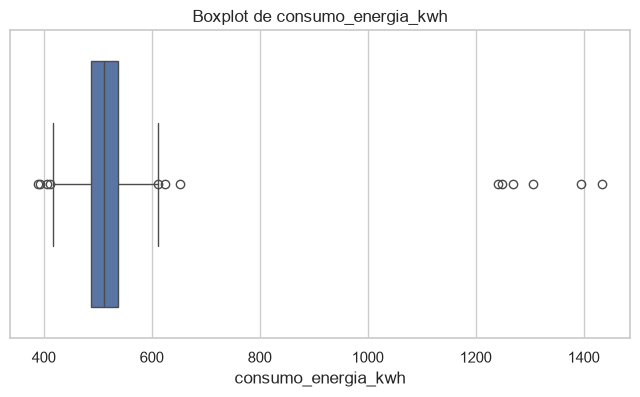

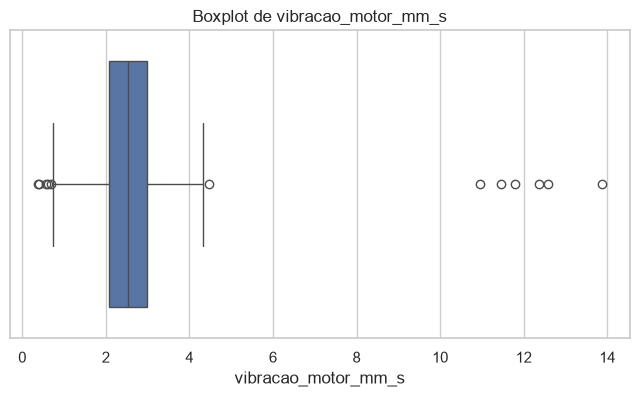

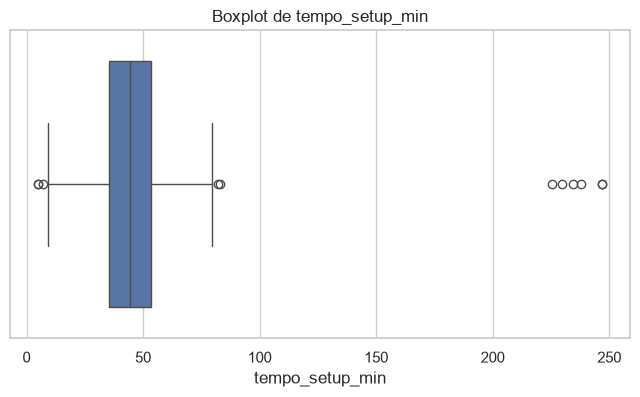

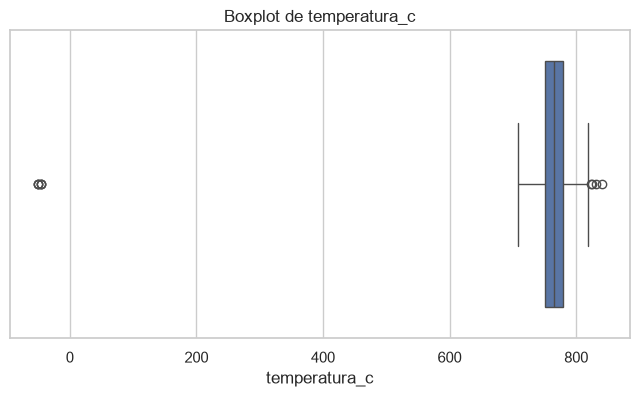

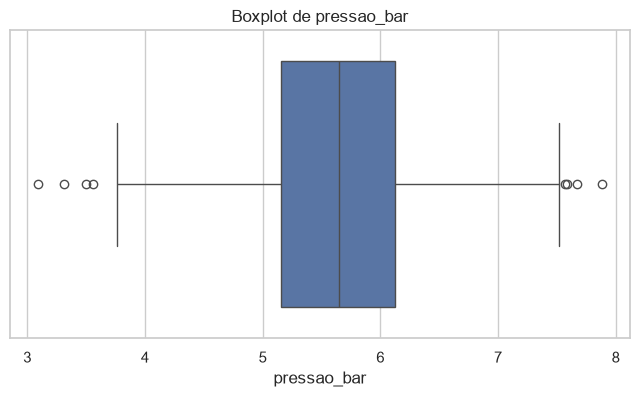


Resumo de Outliers:
              Variável  Limite Inferior  Limite Superior  Qtd Outliers  \
0  consumo_energia_kwh           413.78           612.31            13   
1  vibracao_motor_mm_s             0.70             4.37            12   
2      tempo_setup_min             8.54            80.03            11   
3        temperatura_c           707.19           821.98            10   
4          pressao_bar             3.72             7.57             8   

   % Outliers  
0        1.10  
1        1.01  
2        0.93  
3        0.84  
4        0.67  

---------Justificativa-------------
Como os dados já foram tratados em termos de valores plausiveis e ausentes opto pela limitar por winsorização, uma vez que a regressão linear é sensível a outliers

Resumo de Outliers:
              Variável  Limite Inferior  Limite Superior  Qtd Outliers  \
0  consumo_energia_kwh           413.78           612.31             0   
1  vibracao_motor_mm_s             0.70             4.37            

In [10]:
# ------------------------------------------------------------
# Atividade 5 — Outliers
# ------------------------------------------------------------

print(f"\n{'='*80}")
print("---------Tratamento de Outliers-------------")
print(f"{'='*80}")

variaveis_outlier = [
    "consumo_energia_kwh",
    "vibracao_motor_mm_s",
    "tempo_setup_min",
    "temperatura_c",
    "pressao_bar"
]

# TODO 1: construir boxplots para cada variável
for col in variaveis_outlier:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=dados_limpos, x=col)
    plt.title(f"Boxplot de {col}")
    plt.show()

# TODO 2: criar uma função para calcular limites por IQR
def limites_iqr(serie, fator=1.5):

    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - fator * IQR
    limite_superior = Q3 + fator * IQR

    return limite_inferior, limite_superior
# TODO 3: aplicar a função às variáveis e avaliar os limites
def check_outliers(variaveis_outlier):
  resumo_outliers = []

  for col in variaveis_outlier:

      li, ls = limites_iqr(dados_limpos[col])

      mask_outlier = (
          (dados_limpos[col] < li) |
          (dados_limpos[col] > ls)
      )

      qtd_outliers = mask_outlier.sum()

      pct_outliers = (
          qtd_outliers / len(dados_limpos)
      ) * 100

      resumo_outliers.append({
          "Variável": col,
          "Limite Inferior": round(li, 2),
          "Limite Superior": round(ls, 2),
          "Qtd Outliers": qtd_outliers,
          "% Outliers": round(pct_outliers, 2)
      })

  resumo_outliers = pd.DataFrame(resumo_outliers)

  print("\nResumo de Outliers:")
  print(resumo_outliers)

check_outliers(variaveis_outlier)

# TODO 4: decidir a estratégia de tratamento
print(f"\n{'='*80}")
print("---------Justificativa-------------")
print("Como os dados já foram tratados em termos de valores plausiveis e ausentes opto pela limitar por winsorização, uma vez que a regressão linear é sensível a outliers")
print(f"{'='*80}")


for col in variaveis_outlier:

    li, ls = limites_iqr(dados_limpos[col])

    dados_limpos[col] = dados_limpos[col].clip(
        lower=li,
        upper=ls
    )
check_outliers(variaveis_outlier)



# 9. Atividade 6 — Remoção de variáveis irrelevantes ou redundantes

A base contém variáveis propositalmente redundantes e irrelevantes.

Tarefas:

1. Avaliar a correlação entre `energia_sensor_b_kwh` e `consumo_energia_kwh`.
2. Decidir se `energia_sensor_b_kwh` deve ser usada no modelo de regressão.
3. Avaliar se `codigo_campanha` tem sentido industrial.
4. Avaliar se `ruido_aleatorio` deve permanecer.
5. Justificar a remoção ou manutenção de cada variável.

Atenção: variáveis altamente correlacionadas com o alvo podem ser úteis, mas também podem representar vazamento de informação, dependendo de como são coletadas.


---------Variáveis redundantes e irrelevantes-------------
Correlação entre consumo_energia_kwh e energia_sensor_b_kwh: 0.9135


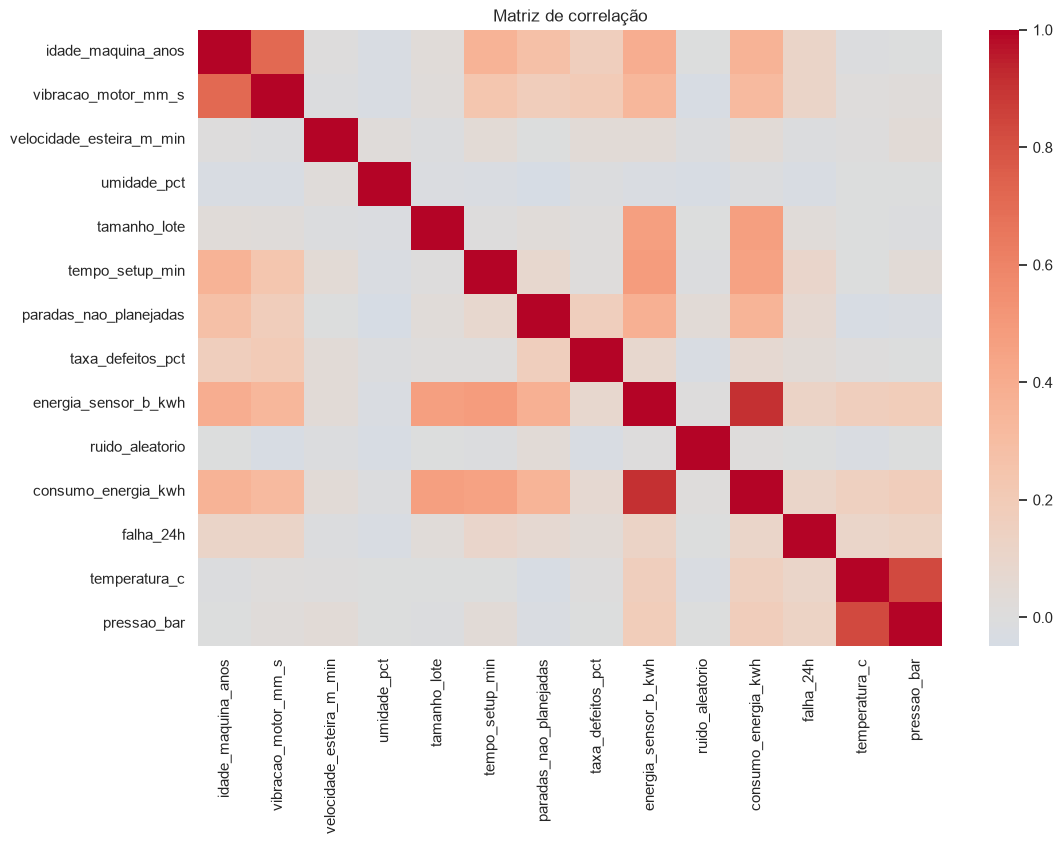


---------Justificativa-------------
registro_id -> Identificador único sem significado preditivo -> Removido
codigo_campanha -> Código administrativo, sem significado físico do processo -> Removido
ruido_aleatorio -> Variável artificial sem relação causal com o fenômeno -> Removido
energia_sensor_b_kwh-> Segundo o livro, Multivariate data analysis Joseph F. Hair, William C Black, Barry J Babin and Rolph E Anderson,
correlação acima de 90% justifica remoção de uma das variaveis, e será aplicado neste trabalho -> Removido

Colunas removidas:
['registro_id', 'codigo_campanha', 'ruido_aleatorio', 'energia_sensor_b_kwh']

Dimensão após remoção:
(1186, 16)


In [11]:
# ------------------------------------------------------------
# Atividade 6 — Variáveis redundantes e irrelevantes
# ------------------------------------------------------------
print(f"\n{'='*80}")
print("---------Variáveis redundantes e irrelevantes-------------")
print(f"{'='*80}")

# TODO 1: calcular matriz de correlação das variáveis numéricas
corr = dados_limpos.select_dtypes(
    include=["int64", "float64"]
).corr()

corr_energia = corr.loc[
    "consumo_energia_kwh",
    "energia_sensor_b_kwh"
]

print(
    f"Correlação entre consumo_energia_kwh "
    f"e energia_sensor_b_kwh: {corr_energia:.4f}"
)

# TODO 2: visualizar correlações por heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlação")
plt.show()

# TODO 3: decidir colunas a remover
colunas_remover = [
    "registro_id",
    "codigo_campanha",
    "ruido_aleatorio",
    "energia_sensor_b_kwh"
]
print(f"\n{'='*80}")
print("---------Justificativa-------------")
print("registro_id -> Identificador único sem significado preditivo -> Removido")
print("codigo_campanha -> Código administrativo, sem significado físico do processo -> Removido")
print("ruido_aleatorio -> Variável artificial sem relação causal com o fenômeno -> Removido")
print("energia_sensor_b_kwh-> Segundo o livro, Multivariate data analysis Joseph F. Hair, William C Black, Barry J Babin and Rolph E Anderson,")
print("correlação acima de 90% justifica remoção de uma das variaveis, e será aplicado neste trabalho -> Removido")

print(f"{'='*80}")


dados_modelagem = dados_limpos.drop(
    columns=colunas_remover
)

print("\nColunas removidas:")
print(colunas_remover)

print("\nDimensão após remoção:")
print(dados_modelagem.shape)

# 10. Atividade 7 — Transformação simbólico-numérica

Modelos como regressão linear, regressão logística, árvore de decisão e floresta aleatória precisam receber os dados em formato numérico.

As variáveis categóricas precisam ser convertidas em variáveis numéricas.

Tarefas:

1. Escolher variáveis categóricas de entrada.
2. Aplicar transformação simbólico-numérica.
3. Usar `OneHotEncoder` para variáveis nominais, como:
   - linha de produção;
   - turno;
   - máquina.
4. Explicar por que `OneHotEncoder` é mais adequado do que codificar `A=1`, `B=2`, `C=3` em variáveis sem ordem natural.
5. Garantir que a transformação seja ajustada apenas nos dados de treino, para evitar vazamento de dados.

A célula abaixo inicia a estrutura, mas você deve completá-la.

In [12]:
dados_modelos = dados_modelagem.copy()


# ------------------------------------------------------------
# Atividade 7 — Transformação simbólico-numérica
# ------------------------------------------------------------

# TODO: definir a base final de modelagem

# Sugestão de colunas categóricas após limpeza

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Variáveis categóricas
variaveis_categoricas = [
    "linha_producao_pad",
    "turno_pad",
    "maquina"
]

# Pipeline para categóricas
transformador_categorico = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

# ColumnTransformer
preprocessador = ColumnTransformer(
    transformers=[
        (
            "cat",
            transformador_categorico,
            variaveis_categoricas
        )
    ],
    remainder="passthrough"
)

# Aplicar transformação
dados_transformados = preprocessador.fit_transform(dados_modelagem)

# Recuperar nomes das colunas geradas pelo OneHotEncoder
nomes_ohe = (
    preprocessador
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(variaveis_categoricas)
)

# Colunas que não foram transformadas
outras_colunas = [
    col for col in dados_modelagem.columns
    if col not in variaveis_categoricas
]

# Criar DataFrame final
dados_modelagem_ohe = pd.DataFrame(
    dados_transformados.toarray() if hasattr(dados_transformados, "toarray") else dados_transformados,
    columns=list(nomes_ohe) + outras_colunas,
    index=dados_modelagem.index
)

print(f"\n{'='*80}")
print("---------Justificativa-------------")
print("Para não induzir ordem não podemos aplicar A=1, B=2, C=3 por exemplo, visto que o modelo de regressão linear é sensível a variaveis categoricas ordinais")

print(f"{'='*80}")

display(dados_modelagem_ohe.head())

dados_modelagem = dados_modelagem_ohe.copy()


---------Justificativa-------------
Para não induzir ordem não podemos aplicar A=1, B=2, C=3 por exemplo, visto que o modelo de regressão linear é sensível a variaveis categoricas ordinais


,linha_producao_pad_A,linha_producao_pad_B,linha_producao_pad_C,turno_pad_manha,turno_pad_noite,turno_pad_tarde,maquina_M01,maquina_M02,maquina_M03,maquina_M04,maquina_M05,maquina_M06,maquina_M07,maquina_M08,idade_maquina_anos,vibracao_motor_mm_s,velocidade_esteira_m_min,umidade_pct,tamanho_lote,tempo_setup_min,paradas_nao_planejadas,taxa_defeitos_pct,consumo_energia_kwh,falha_24h,data_registro_pad,temperatura_c,pressao_bar
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,10,2.826,42.87,60.76,1958.0,34.68,3,2.044,540.04,1,2025-01-01 00:00:00,764.04,5.925
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,13,3.252,36.85,25.79,3569.0,48.07,2,2.443,576.34,0,2025-01-01 06:00:00,784.92,6.122258
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,10,3.003,40.38,79.18,2014.0,26.37,0,2.15,477.44,0,2025-01-01 12:00:00,751.23,5.337
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9,2.526,35.66,61.34,2943.0,49.33,0,1.956,521.25,0,2025-01-01 18:00:00,792.82,6.539
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8,2.431,44.73,63.36,2728.0,21.74,1,2.022,443.24,0,2025-01-02 00:00:00,741.905556,3.996263


# 11. Atividade 8 — Transformação numérica-numérica

Além de transformar categorias em números, você também deve transformar variáveis numéricas.

Tarefas:

1. Aplicar imputação em variáveis numéricas.
2. Testar pelo menos uma transformação numérica-numérica:
   - `StandardScaler`;
   - `MinMaxScaler`;
   - `RobustScaler`;
   - transformação logarítmica em variáveis assimétricas.
3. Explicar qual transformação foi escolhida e por quê.
4. Comparar a escala de pelo menos uma variável antes e depois da transformação.

Observação:

- Ridge, Lasso e regressão logística são sensíveis à escala das variáveis.
- Árvores de decisão e florestas aleatórias são menos sensíveis à escala, mas ainda exigem tratamento de ausentes e categóricas.

In [13]:
# ------------------------------------------------------------
# Atividade 8 — Transformação numérica-numérica
# ------------------------------------------------------------

print(f"\n{'='*80}")
print("---------Transformação numérica-numérica-------------")
print(f"{'='*80}")
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
import numpy as np
import pandas as pd

# Sugestão de colunas numéricas
colunas_numericas = [
    "idade_maquina_anos",
    "temperatura_c",
    "pressao_bar",
    "vibracao_motor_mm_s",
    "velocidade_esteira_m_min",
    "umidade_pct",
    "tamanho_lote",
    "tempo_setup_min",
    "paradas_nao_planejadas",
    "taxa_defeitos_pct"
]

check_distribuicao(dados_modelagem,colunas_numericas)


# Variável para transformação logarítmica
coluna_log = ["paradas_nao_planejadas"]

# Variáveis para StandardScaler
colunas_standard = [
    "idade_maquina_anos",
    "temperatura_c",
    "pressao_bar",
    "vibracao_motor_mm_s",
    "velocidade_esteira_m_min",
    "umidade_pct",
    "tamanho_lote",
    "tempo_setup_min",
    "taxa_defeitos_pct"
]

# Pipeline logarítmico
transformador_log = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("log", FunctionTransformer(np.log1p, validate=False))
    ]
)

# Pipeline StandardScaler
transformador_standard = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ]
)

# Pré-processador
preprocessador = ColumnTransformer(
    transformers=[
        ("log", transformador_log, coluna_log),
        ("std", transformador_standard, colunas_standard)
    ],
    remainder="passthrough"
)

# Aplicar transformação
dados_transformados = preprocessador.fit_transform(dados_modelagem)

# Colunas não transformadas
outras_colunas = [
    col for col in dados_modelagem.columns
    if col not in coluna_log + colunas_standard
]

# Nome final das colunas
nomes_colunas = (
    coluna_log +
    colunas_standard +
    outras_colunas
)

# DataFrame final
dados_modelagem_transformado = pd.DataFrame(
    dados_transformados,
    columns=nomes_colunas,
    index=dados_modelagem.index
)

display(dados_modelagem_transformado)


---------Transformação numérica-numérica-------------
                   Variável  NaN  % NaN               Distribuição  Outliers  \
0        idade_maquina_anos    0    0.0  Aproximadamente simétrica         0   
1             temperatura_c    0    0.0  Aproximadamente simétrica         0   
2               pressao_bar    0    0.0  Aproximadamente simétrica         0   
3       vibracao_motor_mm_s    0    0.0  Aproximadamente simétrica         0   
4  velocidade_esteira_m_min    0    0.0  Aproximadamente simétrica        18   
5               umidade_pct    0    0.0  Aproximadamente simétrica        12   
6              tamanho_lote    0    0.0  Aproximadamente simétrica         0   
7           tempo_setup_min    0    0.0  Aproximadamente simétrica         0   
8    paradas_nao_planejadas    0    0.0     Fortemente assimétrica        50   
9         taxa_defeitos_pct    0    0.0  Aproximadamente simétrica         5   

   % Outliers Sugestão Imputação  
0        0.00              Mé

,paradas_nao_planejadas,idade_maquina_anos,temperatura_c,pressao_bar,vibracao_motor_mm_s,velocidade_esteira_m_min,umidade_pct,tamanho_lote,tempo_setup_min,taxa_defeitos_pct,linha_producao_pad_A,linha_producao_pad_B,linha_producao_pad_C,turno_pad_manha,turno_pad_noite,turno_pad_tarde,maquina_M01,maquina_M02,maquina_M03,maquina_M04,maquina_M05,maquina_M06,maquina_M07,maquina_M08,consumo_energia_kwh,falha_24h,data_registro_pad
0,1.386294,0.517175,-0.022832,0.378172,0.428469,0.238077,0.501508,-0.727642,-0.743076,-0.35216,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,540.04,1,2025-01-01 00:00:00
1,1.098612,1.209988,0.92709,0.648221,1.041718,-1.163954,-2.362764,0.605317,0.275863,0.107072,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,576.34,0,2025-01-01 06:00:00
2,0.0,0.517175,-0.605615,-0.426809,0.68327,-0.341833,2.010227,-0.681307,-1.375442,-0.230159,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,477.44,0,2025-01-01 12:00:00
3,0.0,0.286238,1.286495,1.218748,-0.003396,-1.441099,0.549014,0.087357,0.371745,-0.453445,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,521.25,0,2025-01-01 18:00:00
4,0.693147,0.0553,-1.029824,-2.2623,-0.140154,0.671262,0.714466,-0.090536,-1.727771,-0.377481,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,443.24,0,2025-01-02 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,1.098612,1.440926,-0.529639,-0.39806,1.781648,0.16355,-1.009668,0.413357,0.33674,0.886271,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,513.41,0,2025-10-26 18:00:00
1196,1.098612,-0.637512,0.474421,0.686201,0.211097,1.006632,1.624448,0.633449,-0.985826,-0.754996,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,508.43,0,2025-10-27 00:00:00
1197,1.098612,1.671863,-0.338108,-0.395322,-0.003396,-0.809953,-0.257765,1.544428,-0.605341,0.65723,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,573.63,0,2025-10-27 06:00:00
1198,0.693147,-0.86845,-0.912044,-0.586984,-1.699188,-0.600347,-0.418302,-1.553399,0.680699,0.011543,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,497.08,0,2025-10-27 12:00:00


# 12. Atividade 9 — Separação entre treino e teste

Antes de treinar modelos, você deve separar os dados em treino e teste.

Você terá dois problemas:

1. **Regressão:** prever `consumo_energia_kwh`.
2. **Classificação:** prever `falha_24h`.

Tarefas:

1. Criar `X_reg` e `y_reg`.
2. Criar `X_clf` e `y_clf`.
3. Separar treino e teste.
4. Usar `stratify=y_clf` no problema de classificação.
5. Justificar por que a separação deve ocorrer antes de ajustar transformações como `StandardScaler` e `OneHotEncoder`.

A célula abaixo contém a estrutura inicial.

In [14]:
# ------------------------------------------------------------
# Atividade 9 — Separação treino/teste
# ------------------------------------------------------------

print(f"\n{'='*80}")
print("---------Separação treino/teste-------------")
print(f"{'='*80}")

from sklearn.model_selection import train_test_split

# Problema de regressão
alvo_regressao = "consumo_energia_kwh"

# Problema de classificação
alvo_classificacao = "falha_24h"

dados_modelagem = dados_modelagem.drop(columns=["data_registro_pad"])

# TODO: definir X_reg, y_reg, X_clf e y_clf
y_reg = dados_modelagem[alvo_regressao]

X_reg = dados_modelagem.drop(
    columns=[alvo_regressao, alvo_classificacao]
)

X_clf = dados_modelagem.drop(
    columns=[alvo_regressao, alvo_classificacao]
)

y_clf = dados_modelagem[alvo_classificacao]

# TODO: separar treino e teste para regressão

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=RANDOM_STATE
)

# TODO: separar treino e teste para classificação

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

# Verificação dos tamanhos
print("Regressão:")
print(f"Treino: {X_train_reg.shape}")
print(f"Teste : {X_test_reg.shape}")

print("\nClassificação:")
print(f"Treino: {X_train_clf.shape}")
print(f"Teste : {X_test_clf.shape}")


---------Separação treino/teste-------------
Regressão:
Treino: (889, 24)
Teste : (297, 24)

Classificação:
Treino: (889, 24)
Teste : (297, 24)


# 13. Atividade 10 — Regressão Ridge

Agora você deve treinar um modelo Ridge para prever o consumo de energia.

Tarefas:

1. Criar um `Pipeline` com:
   - pré-processamento;
   - modelo `Ridge`.
2. Testar diferentes valores de `alpha`.
3. Avaliar o modelo usando:
   - MAE;
   - RMSE;
   - R².
4. Criar gráfico de valores reais versus valores previstos.
5. Interpretar os resultados.

Perguntas para responder:

1. O modelo está errando muito em média?
2. O R² indica boa explicação da variação do consumo?
3. O aumento de `alpha` melhorou ou piorou o resultado?


---------Regressão Ridge-------------

---------Observação-------------
preprocessamento já executado em céculas anteriores
    alpha        MAE       RMSE        R2
0    0.01  18.988764  23.483285  0.628302
1    0.10  18.988631  23.483175  0.628305
2    1.00  18.987303  23.482101  0.628339
3   10.00  18.974772  23.473647  0.628607
4  100.00  18.969806  23.507252  0.627543

Melhor alpha: 10.0
MAE  = 18.9748
RMSE = 23.4736
R²   = 0.6286


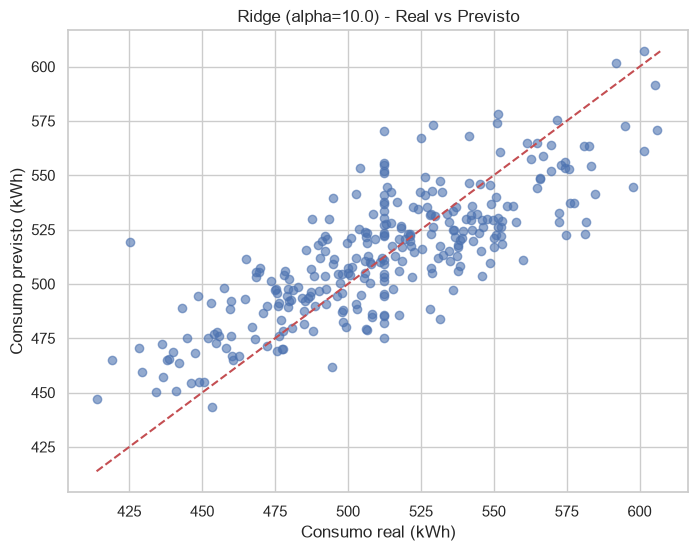


---------Avaliação-------------
1. O modelo está errando muito em média? Não
2. O R² indica boa explicação da variação do consumo? Sim
3. O aumento de alpha melhorou ou piorou o resultado? Melhorou levemente


In [15]:
# ------------------------------------------------------------
# Atividade 10 — Regressão Ridge
# ------------------------------------------------------------

print(f"\n{'='*80}")
print("---------Regressão Ridge-------------")
print(f"{'='*80}")

from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Valores de alpha a serem testados
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

resultados_ridge = []

print(f"\n{'='*80}")
print("---------Observação-------------")
print("preprocessamento já executado em céculas anteriores")
print(f"{'='*80}")

for alpha in alphas:

    modelo_ridge = Pipeline(
        steps=[
            ("modelo", Ridge(alpha=alpha))
        ]
    )

    # Treinamento
    modelo_ridge.fit(X_train_reg, y_train_reg)

    # Previsão
    y_pred = modelo_ridge.predict(X_test_reg)

    # Métricas
    mae = mean_absolute_error(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    r2 = r2_score(y_test_reg, y_pred)

    resultados_ridge.append(
        {
            "alpha": alpha,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        }
    )

# Tabela de resultados
resultados_ridge = pd.DataFrame(resultados_ridge)

print(resultados_ridge)

# Melhor modelo (maior R²)
melhor_alpha = resultados_ridge.loc[
    resultados_ridge["R2"].idxmax(),
    "alpha"
]

print(f"\nMelhor alpha: {melhor_alpha}")

modelo_ridge = Pipeline(
    steps=[
        ("modelo", Ridge(alpha=melhor_alpha))
    ]
)

modelo_ridge.fit(X_train_reg, y_train_reg)

y_pred_ridge = modelo_ridge.predict(X_test_reg)

mae_ridge = mean_absolute_error(y_test_reg, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge))
r2_ridge = r2_score(y_test_reg, y_pred_ridge)

print(f"MAE  = {mae_ridge:.4f}")
print(f"RMSE = {rmse_ridge:.4f}")
print(f"R²   = {r2_ridge:.4f}")

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_reg,
    y_pred_ridge,
    alpha=0.6
)

lim_min = min(y_test_reg.min(), y_pred_ridge.min())
lim_max = max(y_test_reg.max(), y_pred_ridge.max())

plt.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    "r--"
)

plt.xlabel("Consumo real (kWh)")
plt.ylabel("Consumo previsto (kWh)")
plt.title(f"Ridge (alpha={melhor_alpha}) - Real vs Previsto")

plt.grid(True)
plt.show()

print(f"\n{'='*80}")
print("---------Avaliação-------------")
print("1. O modelo está errando muito em média? Não")
print("2. O R² indica boa explicação da variação do consumo? Sim")
print("3. O aumento de alpha melhorou ou piorou o resultado? Melhorou levemente")
print(f"{'='*80}")



resultado_ridge = {
    "alpha": melhor_alpha,
    "MAE": mae_ridge,
    "RMSE": rmse_ridge,
    "R2": r2_ridge
}

#Sobre o uso de pipeline
O recurso **`Pipeline`** do `scikit-learn` permite encadear várias etapas de processamento em uma única estrutura. Ele é muito útil porque garante que o mesmo pré-processamento aplicado no treino será aplicado também nos dados de teste e em dados novos.

Em aprendizado de máquina, um pipeline normalmente segue esta lógica:

```text
dados brutos → pré-processamento → modelo → previsão
```

Por exemplo:

```text
dados com variáveis numéricas e categóricas
        ↓
padronização das variáveis numéricas
        ↓
one-hot encoding das variáveis categóricas
        ↓
modelo de regressão linear
        ↓
previsão do valor numérico
```

## 1. Exemplo simples: Pipeline apenas com variáveis numéricas

Imagine que `X` contém somente atributos numéricos e `y` é a variável-alvo da regressão.

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline_regressao = Pipeline(steps=[
    ("padronizacao", StandardScaler()),
    ("modelo", LinearRegression())
])
```

Nesse exemplo, o pipeline tem duas etapas:

```python
("padronizacao", StandardScaler())
```

Essa etapa aplica a padronização:

```text
x_novo = (x - média) / desvio padrão
```

Ela é útil porque coloca as variáveis numéricas em escalas comparáveis.

```python
("modelo", LinearRegression())
```

Essa etapa aplica o modelo de **regressão linear**.

Depois de criar o pipeline, usamos normalmente:

```python
pipeline_regressao.fit(X_train, y_train)
```

O método `.fit()` faz duas coisas:

```text
1. ajusta o StandardScaler usando os dados de treino;
2. treina a regressão linear usando os dados transformados.
```

Para prever:

```python
y_pred = pipeline_regressao.predict(X_test)
```

O método `.predict()` aplica automaticamente a mesma padronização em `X_test` e depois gera as previsões.

---

## 2. Exemplo mais realista: variáveis numéricas e categóricas

Em problemas industriais, normalmente temos variáveis como:

```text
temperatura_forno_c        → numérica
pressao_linha_bar          → numérica
vibracao_motor_mm_s        → numérica
turno                      → categórica
maquina                    → categórica
tipo_produto               → categórica
```

Nesse caso, precisamos tratar variáveis numéricas e categóricas de formas diferentes.

Para isso usamos o `ColumnTransformer`.

```python
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
```

Primeiro, separamos os tipos de atributos:

```python
variaveis_numericas = [
    "temperatura_forno_c",
    "pressao_linha_bar",
    "vibracao_motor_mm_s"
]

variaveis_categoricas = [
    "turno",
    "maquina",
    "tipo_produto"
]
```

Agora definimos o pré-processamento:

```python
pre_processamento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), variaveis_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), variaveis_categoricas)
    ]
)
```

Aqui temos duas transformações:

```python
("num", StandardScaler(), variaveis_numericas)
```

Aplica padronização somente nas variáveis numéricas.

```python
("cat", OneHotEncoder(handle_unknown="ignore"), variaveis_categoricas)
```

Aplica **one-hot encoding** nas variáveis categóricas.

O parâmetro:

```python
handle_unknown="ignore"
```

evita erro se aparecer, nos dados de teste ou em dados novos, uma categoria que não existia no treino.

Agora montamos o pipeline completo:

```python
pipeline_regressao_linear = Pipeline(steps=[
    ("pre_processamento", pre_processamento),
    ("modelo", LinearRegression())
])
```

A estrutura final fica assim:

```text
Pipeline
│
├── pre_processamento
│   ├── StandardScaler nas variáveis numéricas
│   └── OneHotEncoder nas variáveis categóricas
│
└── modelo
    └── LinearRegression
```

---

## 3. Treinando o pipeline

Depois de separar os dados em treino e teste:

```python
from sklearn.model_selection import train_test_split

X = dados.drop(columns="consumo_energia_kwh")
y = dados["consumo_energia_kwh"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
```

Treinamos o pipeline:

```python
pipeline_regressao_linear.fit(X_train, y_train)
```

Esse comando ajusta tudo de uma vez:

```text
1. calcula média e desvio padrão das variáveis numéricas no treino;
2. aprende as categorias das variáveis categóricas no treino;
3. transforma os dados;
4. treina a regressão linear.
```

---

## 4. Fazendo previsões

```python
y_pred = pipeline_regressao_linear.predict(X_test)
```

Aqui o pipeline:

```text
1. aplica o mesmo pré-processamento em X_test;
2. envia os dados transformados para o modelo;
3. retorna as previsões.
```

---

## 5. Avaliando o modelo

Para regressão, podemos usar métricas como MAE, RMSE e R².

```python
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
```

Interpretação:

```text
MAE  → erro absoluto médio.
RMSE → penaliza mais erros grandes.
R²   → proporção da variabilidade da variável-alvo explicada pelo modelo.
```

---

## 6. Exemplo completo

```python
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Separação entre atributos de entrada e variável-alvo
X = dados.drop(columns="consumo_energia_kwh")
y = dados["consumo_energia_kwh"]

# Separação entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Definição das colunas
variaveis_numericas = [
    "temperatura_forno_c",
    "pressao_linha_bar",
    "vibracao_motor_mm_s"
]

variaveis_categoricas = [
    "turno",
    "maquina",
    "tipo_produto"
]

# Pré-processamento
pre_processamento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), variaveis_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), variaveis_categoricas)
    ]
)

# Pipeline completo
pipeline_regressao_linear = Pipeline(steps=[
    ("pre_processamento", pre_processamento),
    ("modelo", LinearRegression())
])

# Treinamento
pipeline_regressao_linear.fit(X_train, y_train)

# Previsão
y_pred = pipeline_regressao_linear.predict(X_test)

# Avaliação
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
```

---

## 7. Principal vantagem do Pipeline

A principal vantagem é evitar **vazamento de dados**.

Por exemplo, não devemos calcular a média e o desvio padrão usando todos os dados antes da separação treino/teste. Isso faria o modelo “ver” informações do conjunto de teste durante o treino.

Com `Pipeline`, o correto acontece automaticamente:

```text
fit() no treino:
    aprende transformações somente com X_train

predict() no teste:
    aplica as transformações aprendidas no treino em X_test
```

Portanto, o pipeline deixa o processo mais organizado, mais seguro e mais próximo do que seria usado em um sistema real de aprendizado de máquina.


# 14. Atividade 11 — Regressão Lasso

Agora você deve treinar um modelo Lasso.

O Lasso também é uma regressão linear regularizada, mas pode zerar coeficientes de variáveis, funcionando como uma forma de seleção de atributos.

Tarefas:

1. Criar um `Pipeline` com:
   - pré-processamento;
   - modelo `Lasso`.
2. Testar diferentes valores de `alpha`.
3. Avaliar o modelo usando:
   - MAE;
   - RMSE;
   - R².
4. Comparar Ridge e Lasso.
5. Avaliar se o Lasso reduziu o número de variáveis efetivamente usadas.

Perguntas para responder:

1. O Lasso teve desempenho melhor ou pior que Ridge?
2. Alguma variável parece ter sido descartada pelo Lasso?
3. O valor de `alpha` escolhido foi adequado?

In [16]:
print(f"\n{'='*80}")
print("---------Regressão Lasso-------------")
print(f"{'='*80}")


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

dados = dados_modelos

# Separação entre atributos de entrada e variável-alvo
y = dados["consumo_energia_kwh"]
X = dados.drop(columns="consumo_energia_kwh")


# Separação entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Variável para transformação logarítmica
coluna_log = ["paradas_nao_planejadas"]

# Variáveis para StandardScaler
colunas_standard = [
    "idade_maquina_anos",
    "temperatura_c",
    "pressao_bar",
    "vibracao_motor_mm_s",
    "velocidade_esteira_m_min",
    "umidade_pct",
    "tamanho_lote",
    "tempo_setup_min",
    "taxa_defeitos_pct"
]

# Variáveis categóricas
variaveis_categoricas = [
    "linha_producao_pad",
    "turno_pad",
    "maquina"
]

# Pipeline logarítmico
transformador_log = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, validate=False))
    ]
)

# Pipeline StandardScaler
transformador_standard = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ]
)




# Pipeline para categóricas
transformador_categorico = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)



# Pré-processamento
pre_processamento = ColumnTransformer(
    transformers=[
        ("log", transformador_log, coluna_log),
        ("std", transformador_standard, colunas_standard),
        ("cat", transformador_categorico, variaveis_categoricas)
    ]
)

alphas = [0.0001, 0.001, 0.01, 0.1, 1.0]

resultados_lasso = []

for alpha in alphas:

    modelo_lasso = Pipeline(
        steps=[
            ("preprocessamento", pre_processamento),
            (
                "modelo",
                Lasso(
                    alpha=alpha,
                    max_iter=10000,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )

    modelo_lasso.fit(
        X_train,
        y_train
    )

    y_pred = modelo_lasso.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    resultados_lasso.append(
        {
            "alpha": alpha,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        }
    )

resultados_lasso = pd.DataFrame(
    resultados_lasso
)

display(resultados_lasso)

# Melhor modelo (maior R²)
melhor_alpha = resultados_lasso.loc[
    resultados_lasso["R2"].idxmax(),
    "alpha"
]

print(f"\nMelhor alpha: {melhor_alpha}")

# Pipeline completo
modelo_lasso = Pipeline(
        steps=[
            ("preprocessamento", pre_processamento),
            (
                "modelo",
                Lasso(
                    alpha=alpha,
                    max_iter=10000,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )
# Treinamento
modelo_lasso.fit(X_train, y_train)

# Previsão
y_pred = modelo_lasso.predict(X_test)

# Avaliação
mae_lasso = mean_absolute_error(y_test, y_pred)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lasso = r2_score(y_test, y_pred)

print("MAE:", mae_lasso)
print("RMSE:", rmse_lasso)
print("R²:", r2_lasso)

resultado_lasso = {
    "alpha": melhor_alpha,
    "MAE": mae_lasso,
    "RMSE": rmse_lasso,
    "R2": r2_lasso
}

# TODO: comparar Ridge e Lasso em uma tabela
resultados_regressao = pd.DataFrame(
    [
        resultado_ridge,
        resultado_lasso
    ],
    index=["Ridge", "Lasso"]
)

display(resultados_regressao)

coeficientes = (
    modelo_lasso
    .named_steps["modelo"]
    .coef_
)

n_coef_zero = np.sum(
    coeficientes == 0
)

n_coef_total = len(
    coeficientes
)

print(
    f"Coeficientes zerados: "
    f"{n_coef_zero}/{n_coef_total}"
)

print(f"\n{'='*80}")
print("---------Avaliação-------------")
print("1. O Lasso teve desempenho melhor ou pior que Ridge? Avaliando R2 e RMSE o modelo Ridge teve melhor performance")
print("2. Alguma variável parece ter sido descartada pelo Lasso? Avaliando o coeficiente das variriaveis descartou 17 variaveis")
print("3. O valor de `alpha` escolhido foi adequado? Melhorou levemente")
print(f"{'='*80}")



---------Regressão Lasso-------------


,alpha,MAE,RMSE,R2
0,0.0001,19.418844,24.206665,0.626928
1,0.0010,19.419680,24.207079,0.626915
2,0.0100,19.428107,24.211434,0.626781
3,0.1000,19.513354,24.268356,0.625024
4,1.0000,20.135041,24.752176,0.609924



Melhor alpha: 0.0001
MAE: 20.13504078811908
RMSE: 24.752175815267815
R²: 0.6099238720950517


,alpha,MAE,RMSE,R2
Ridge,10.0000,18.974772,23.473647,0.628607
Lasso,0.0001,20.135041,24.752176,0.609924


Coeficientes zerados: 17/24

---------Avaliação-------------
1. O Lasso teve desempenho melhor ou pior que Ridge? Avaliando R2 e RMSE o modelo Ridge teve melhor performance
2. Alguma variável parece ter sido descartada pelo Lasso? Avaliando o coeficiente das variriaveis descartou 17 variaveis
3. O valor de `alpha` escolhido foi adequado? Melhorou levemente


# 15. Atividade 12 — Regressão logística

Nesta etapa, você deve treinar uma regressão logística para prever `falha_24h`.

Apesar do nome, a regressão logística é usada para classificação.

Tarefas:

1. Criar um `Pipeline` com:
   - pré-processamento;
   - `LogisticRegression`.
2. Treinar o modelo.
3. Avaliar usando:
   - matriz de confusão;
   - acurácia;
   - precisão;
   - recall;
   - F1-score;
   - ROC-AUC.
4. Interpretar os erros:
   - falsos positivos;
   - falsos negativos.
5. Verificar se existe desbalanceamento entre as classes.

Perguntas para responder:

1. A acurácia é suficiente para avaliar esse problema?
2. É mais grave prever que não haverá falha quando haverá, ou o contrário?
3. O recall da classe de falha é satisfatório?


---------Regressão Lasso-------------


falha_24h
0    0.945194
1    0.054806
Name: proportion, dtype: float64

Acurácia : 0.6639
Precisão : 0.0864
Recall   : 0.5385
F1-score : 0.1489
ROC-AUC  : 0.6995

Relatório:
              precision    recall  f1-score   support

           0       0.96      0.67      0.79       225
           1       0.09      0.54      0.15        13

    accuracy                           0.66       238
   macro avg       0.52      0.60      0.47       238
weighted avg       0.91      0.66      0.76       238



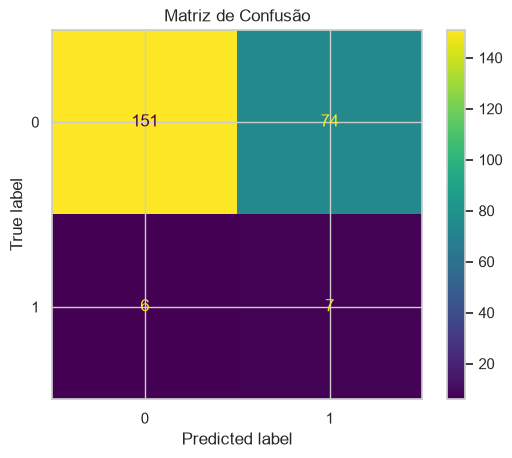


---------Avaliação-------------
1. A acurácia é suficiente para avaliar esse problema? Não pois a classe alvo é desbalanciada, necessitando de outras métricas
2. É mais grave prever que não haverá falha quando haverá, ou o contrário? O Falso negativo é uma falha grave no modelo, pois pode mascarar uma real falha.
3. O recall da classe de falha é satisfatório? Quanto maior, menos falhas reais são perdidas, logo 53% é considerado baixo


In [17]:
# ------------------------------------------------------------
# Atividade 12 — Regressão logística
# ------------------------------------------------------------

print(f"\n{'='*80}")
print("---------Regressão Lasso-------------")
print(f"{'='*80}")




from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

dados = dados_modelos

# Separação entre atributos de entrada e variável-alvo
y = dados["falha_24h"]
X = dados.drop(columns="falha_24h")


# Separação entre treino e teste
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# TODO: verificar balanceamento das classes
display(y.value_counts(normalize=True))


# Variável para transformação logarítmica
coluna_log = ["paradas_nao_planejadas"]

# Variáveis para StandardScaler
colunas_standard = [
    "idade_maquina_anos",
    "temperatura_c",
    "pressao_bar",
    "vibracao_motor_mm_s",
    "velocidade_esteira_m_min",
    "umidade_pct",
    "tamanho_lote",
    "tempo_setup_min",
    "taxa_defeitos_pct"
]

# Variáveis categóricas
variaveis_categoricas = [
    "linha_producao_pad",
    "turno_pad",
    "maquina"
]

# Pipeline logarítmico
transformador_log = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, validate=False))
    ]
)

# Pipeline StandardScaler
transformador_standard = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ]
)




# Pipeline para categóricas
transformador_categorico = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)



# Pré-processamento
pre_processamento = ColumnTransformer(
    transformers=[
        ("log", transformador_log, coluna_log),
        ("std", transformador_standard, colunas_standard),
        ("cat", transformador_categorico, variaveis_categoricas)
    ]
)



# TODO: criar pipeline da regressão logística
modelo_logistico = Pipeline(steps=[
    ("preprocessamento", pre_processamento),
    ("modelo", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# TODO: treinar
modelo_logistico.fit(X_train_clf, y_train_clf)

# TODO: prever classes e probabilidades
y_pred_clf = modelo_logistico.predict(
    X_test_clf
)

y_prob_clf = modelo_logistico.predict_proba(
    X_test_clf
)[:, 1]

# TODO: calcular métricas
acuracia = accuracy_score(
    y_test_clf,
    y_pred_clf
)

precisao = precision_score(
    y_test_clf,
    y_pred_clf
)

recall = recall_score(
    y_test_clf,
    y_pred_clf
)

f1 = f1_score(
    y_test_clf,
    y_pred_clf
)

roc_auc = roc_auc_score(
    y_test_clf,
    y_prob_clf
)

print(f"Acurácia : {acuracia:.4f}")
print(f"Precisão : {precisao:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")


resultado_logistico = {
    "Acurácia": acuracia,
    "Precisão": precisao,
    "Recall": recall,
    "F1-score": f1,
    "ROC-AUC":roc_auc
}


print("\nRelatório:")
print(
    classification_report(
        y_test_clf,
        y_pred_clf
    )
)


# TODO: matriz de confusão
cm = confusion_matrix(
    y_test_clf,
    y_pred_clf
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Matriz de Confusão")
plt.show()


print(f"\n{'='*80}")
print("---------Avaliação-------------")
print("1. A acurácia é suficiente para avaliar esse problema? Não pois a classe alvo é desbalanciada, necessitando de outras métricas")
print("2. É mais grave prever que não haverá falha quando haverá, ou o contrário? O Falso negativo é uma falha grave no modelo, pois pode mascarar uma real falha.")
print("3. O recall da classe de falha é satisfatório? Quanto maior, menos falhas reais são perdidas, logo 53% é considerado baixo")
print(f"{'='*80}")






# 16. Atividade 13 — Árvore de decisão

Agora você deve treinar uma árvore de decisão para classificação.

A árvore de decisão é um modelo interpretável, pois permite visualizar regras de decisão baseadas nos atributos.

Tarefas:

1. Criar um `Pipeline` com:
   - pré-processamento;
   - `DecisionTreeClassifier`.
2. Testar diferentes valores de:
   - `max_depth`;
   - `min_samples_leaf`;
   - `criterion`.
3. Avaliar as métricas de classificação.
4. Comparar desempenho em treino e teste para investigar sobreajuste.
5. Visualizar uma árvore pequena.
6. Interpretar algumas regras da árvore.

Perguntas para responder:

1. A árvore ficou muito profunda?
2. O modelo apresentou overfitting?
3. Quais variáveis parecem ser mais importantes?


---------Árvore de decisão-------------


falha_24h
0    0.945194
1    0.054806
Name: proportion, dtype: float64

,criterion,max_depth,min_samples_leaf,accuracy,f1
28,entropy,8,10,0.819328,0.295082
27,entropy,8,5,0.827731,0.280702
29,entropy,8,20,0.794118,0.268657
13,gini,8,10,0.794118,0.246154
25,entropy,6,10,0.638655,0.218182


Melhor combinação de parametros
criterion            entropy
max_depth                  8
min_samples_leaf          10
accuracy            0.819328
f1                  0.295082
Name: 28, dtype: object
Acurácia : 0.8193
Precisão : 0.1875
Recall   : 0.6923
F1-score : 0.2951
ROC-AUC  : 0.8012
              precision    recall  f1-score   support

           0       0.98      0.83      0.90       225
           1       0.19      0.69      0.30        13

    accuracy                           0.82       238
   macro avg       0.58      0.76      0.60       238
weighted avg       0.94      0.82      0.86       238



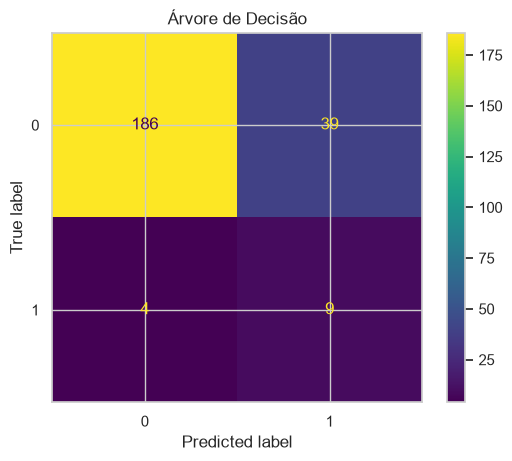

Acurácia treino: 0.8428
Acurácia teste : 0.8193
Diferença      : 0.0235


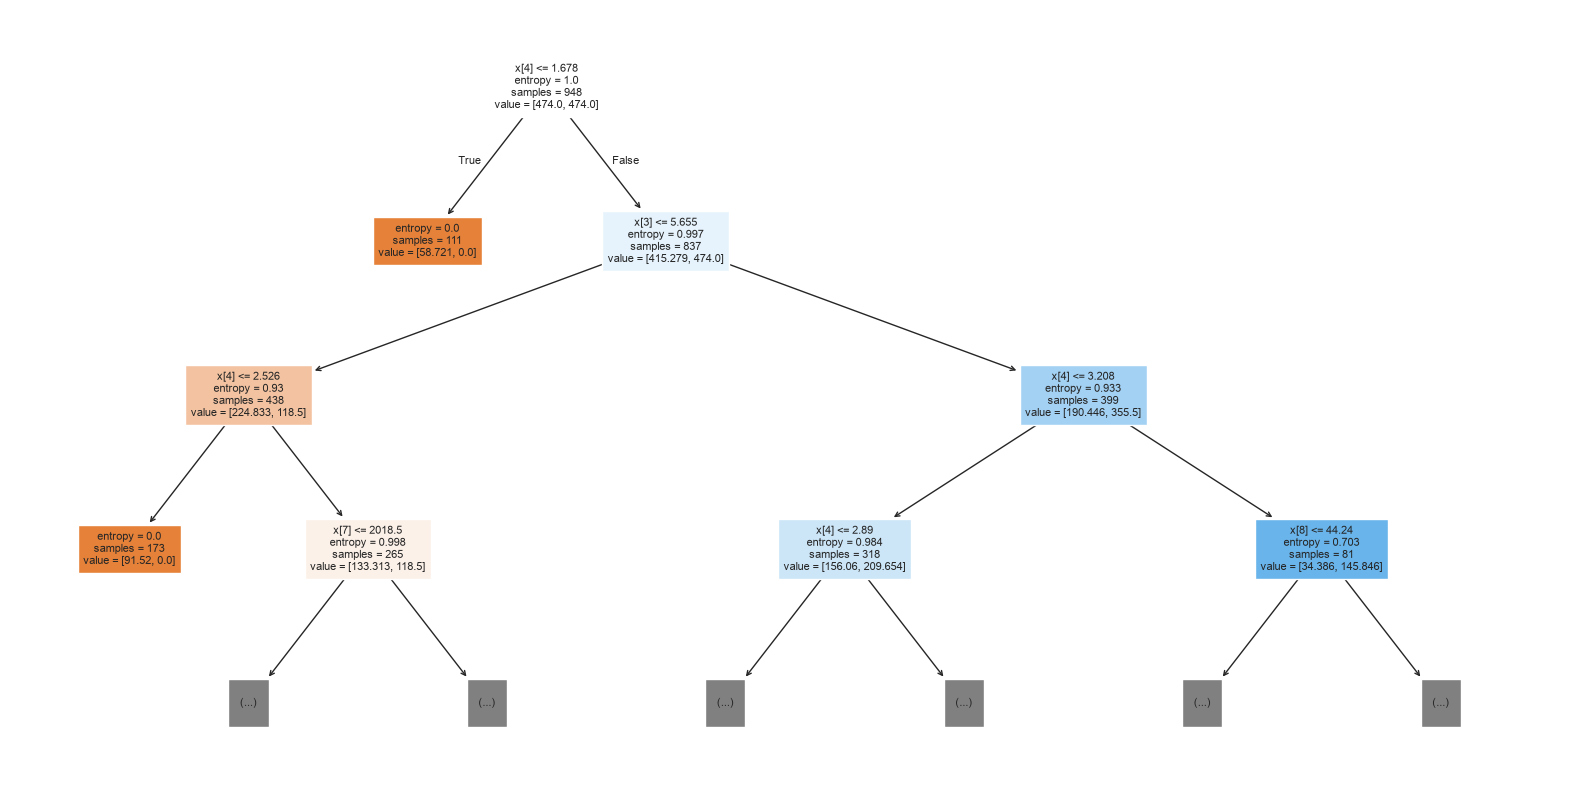

,importancia
4,0.342400
3,0.142487
8,0.137404
2,0.116737
7,0.088612
5,0.066339
6,0.040846
14,0.033407
0,0.031769
1,0.000000


Variaveis mais relevantes: umidade_pct, velocidade_esteira_m_min, taxa_defeitos_pct, ...
8

---------Avaliação-------------
1. A árvore ficou muito profunda? Não
2. O modelo apresentou overfitting? Não pois não houve diferença significativa entre a acurácia de treino e teste ficando em 2%
3. Quais variáveis parecem ser mais importantes? O top 3 variaveis são: umidade_pct, velocidade_esteira_m_min, taxa_defeitos_pct


In [18]:
# ------------------------------------------------------------
# Atividade 13 — Árvore de decisão
# ------------------------------------------------------------


print(f"\n{'='*80}")
print("---------Árvore de decisão-------------")
print(f"{'='*80}")

# TODO: criar pipeline da árvore de decisão

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay
)

import pandas as pd
import matplotlib.pyplot as plt

dados = dados_modelos

# Separação entre atributos de entrada e variável-alvo
y = dados["falha_24h"]
X = dados.drop(columns="falha_24h")


# Separação entre treino e teste
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# TODO: verificar balanceamento das classes
display(y.value_counts(normalize=True))


# Variável para transformação logarítmica
coluna_log = ["paradas_nao_planejadas"]

# Variáveis para StandardScaler
colunas_standard = [
    "idade_maquina_anos",
    "temperatura_c",
    "pressao_bar",
    "vibracao_motor_mm_s",
    "velocidade_esteira_m_min",
    "umidade_pct",
    "tamanho_lote",
    "tempo_setup_min",
    "taxa_defeitos_pct"
]

# Variáveis categóricas
variaveis_categoricas = [
    "linha_producao_pad",
    "turno_pad",
    "maquina"
]

# Pipeline logarítmico
transformador_log = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, validate=False))
    ]
)

# Pipeline StandardScaler
# desnecessário para as arvores e florestas
transformador_standard = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        # ("scaler", StandardScaler())
    ]
)



# Pipeline para categóricas
transformador_categorico = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)



# Pré-processamento
pre_processamento = ColumnTransformer(
    transformers=[
        ("log", transformador_log, coluna_log),
        ("std", transformador_standard, colunas_standard),
        ("cat", transformador_categorico, variaveis_categoricas)
    ]
)



resultados_tree = []

for criterion in ["gini", "entropy"]:
    for max_depth in [3, 4, 5, 6, 8]:
        for min_samples_leaf in [5, 10, 20]:

            modelo = Pipeline(
                steps=[
                    ("preprocessamento", pre_processamento),
                    (
                        "modelo",
                        DecisionTreeClassifier(
                            criterion=criterion,
                            max_depth=max_depth,
                            min_samples_leaf=min_samples_leaf,
                            class_weight="balanced",
                            random_state=RANDOM_STATE
                        )
                    )
                ]
            )

            modelo.fit(X_train_clf, y_train_clf)

            y_pred = modelo.predict(X_test_clf)

            resultados_tree.append(
                {
                    "criterion": criterion,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                    "accuracy": accuracy_score(
                        y_test_clf,
                        y_pred
                    ),
                    "f1": f1_score(
                        y_test_clf,
                        y_pred
                    )
                }
            )

resultados_tree = pd.DataFrame(resultados_tree)

display(
    resultados_tree.sort_values(
        "f1",
        ascending=False
    ).head()
)

melhor = resultados_tree.sort_values(
    "f1",
    ascending=False
).iloc[0]

print("Melhor combinação de parametros")
print(melhor)

modelo_arvore = Pipeline(
    steps=[
        ("preprocessamento", pre_processamento),
        (
            "modelo",
            DecisionTreeClassifier(
                criterion=melhor["criterion"],
                max_depth=int(melhor["max_depth"]),
                min_samples_leaf=int(melhor["min_samples_leaf"]),
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)
# TODO: treinar
modelo_arvore.fit(
    X_train_clf,
    y_train_clf
)


# TODO: prever
y_pred_tree = modelo_arvore.predict(
    X_test_clf
)

y_prob_clf = modelo_arvore.predict_proba(
    X_test_clf
)[:, 1]

# TODO: avaliar
# TODO: calcular métricas
acuracia = accuracy_score(
    y_test_clf,
    y_pred_tree
)

precisao = precision_score(
    y_test_clf,
    y_pred_tree
)

recall = recall_score(
    y_test_clf,
    y_pred_tree
)

f1 = f1_score(
    y_test_clf,
    y_pred_tree
)

roc_auc = roc_auc_score(
    y_test_clf,
    y_prob_clf
)

print(f"Acurácia : {acuracia:.4f}")
print(f"Precisão : {precisao:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

resultado_arvore = {
    "Acurácia": acuracia,
    "Precisão": precisao,
    "Recall": recall,
    "F1-score": f1,
    "ROC-AUC":roc_auc
}


print(
    classification_report(
        y_test_clf,
        y_pred_tree
    )
)


# TODO: matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    y_test_clf,
    y_pred_tree
)

plt.title("Árvore de Decisão")
plt.show()

# TODO: comparar métricas de treino e teste
acc_train = accuracy_score(
    y_train_clf,
    modelo_arvore.predict(X_train_clf)
)

acc_test = accuracy_score(
    y_test_clf,
    y_pred_tree
)

print(
    f"Acurácia treino: {acc_train:.4f}"
)

print(
    f"Acurácia teste : {acc_test:.4f}"
)

print(
    f"Diferença      : {acc_train - acc_test:.4f}"
)

# TODO: vizualização da arvore

from sklearn.tree import plot_tree

arvore = modelo_arvore.named_steps["modelo"]

plt.figure(figsize=(20,10))

plot_tree(
    arvore,
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.show()

importancias = pd.DataFrame(
    {
        "importancia":
        modelo_arvore.named_steps["modelo"].feature_importances_
    }
)

importancias = importancias.sort_values(
    "importancia",
    ascending=False
)

display(importancias)
print(f"Variaveis mais relevantes: {X_train_clf.columns[4]}, {X_train_clf.columns[3]}, {X_train_clf.columns[8]}, ...")

print(modelo_arvore.named_steps["modelo"].get_depth())



print(f"\n{'='*80}")
print("---------Avaliação-------------")
print("1. A árvore ficou muito profunda? Não")
print("2. O modelo apresentou overfitting? Não pois não houve diferença significativa entre a acurácia de treino e teste ficando em 2%")
print("3. Quais variáveis parecem ser mais importantes? O top 3 variaveis são: umidade_pct, velocidade_esteira_m_min, taxa_defeitos_pct")
print(f"{'='*80}")


# 17. Atividade 14 — Ensemble com floresta aleatória

Agora você deve treinar uma floresta aleatória.

A floresta aleatória combina várias árvores de decisão treinadas com amostras e subconjuntos de atributos diferentes. A ideia é reduzir a instabilidade de uma única árvore e melhorar a generalização.

Tarefas:

1. Criar um `Pipeline` com:
   - pré-processamento;
   - `RandomForestClassifier`.
2. Testar diferentes valores de:
   - `n_estimators`;
   - `max_depth`;
   - `min_samples_leaf`;
   - `max_features`.
3. Avaliar as métricas de classificação.
4. Comparar com regressão logística e árvore de decisão.
5. Avaliar importâncias das variáveis.
6. Discutir se o ensemble lidou melhor com ruídos e outliers.

Perguntas para responder:

1. A floresta aleatória melhorou o desempenho?
2. Houve ganho em recall da classe de falha?
3. O modelo ficou menos interpretável que a árvore única?
4. Quais atributos aparecem como mais importantes?


---------Floresta Aleatória-------------


falha_24h
0    0.945194
1    0.054806
Name: proportion, dtype: float64

,n_estimators,max_depth,min_samples_leaf,max_features,accuracy,precision,recall,f1
27,100,25.0,5,log2,0.907563,0.235294,0.307692,0.266667
26,100,25.0,5,sqrt,0.907563,0.235294,0.307692,0.266667
33,100,NaN,5,log2,0.907563,0.235294,0.307692,0.266667
32,100,NaN,5,sqrt,0.907563,0.235294,0.307692,0.266667
21,100,20.0,5,log2,0.907563,0.235294,0.307692,0.266667


n_estimators             100
max_depth               25.0
min_samples_leaf           5
max_features            log2
accuracy            0.907563
precision           0.235294
recall              0.307692
f1                  0.266667
Name: 27, dtype: object
Acurácia : 0.9076
Precisão : 0.2353
Recall   : 0.3077
F1-score : 0.2667
ROC-AUC  : 0.7460
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       225
           1       0.24      0.31      0.27        13

    accuracy                           0.91       238
   macro avg       0.60      0.62      0.61       238
weighted avg       0.92      0.91      0.91       238

ROC-AUC: 0.7459829059829061


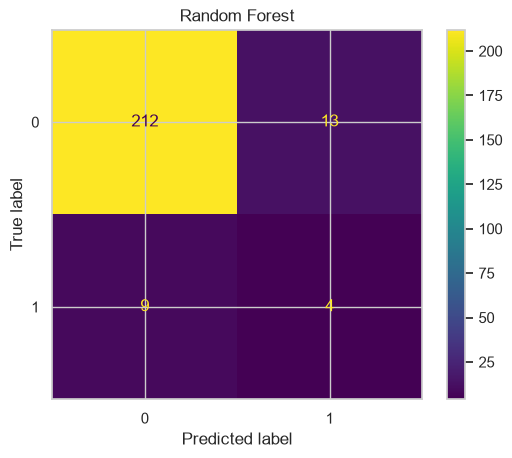

,importancia
3,0.167243
4,0.130787
2,0.108022
8,0.095463
1,0.077945
7,0.077289
9,0.072522
6,0.069328
5,0.062566
0,0.029768


Variaveis mais relevantes: velocidade_esteira_m_min, vibracao_motor_mm_s, umidade_pct, ...

---------Avaliação-------------
1. A floresta aleatória melhorou o desempenho? Não esta totalmente enviesado para a classe Sem Falha mesmo aplicando o parametro class_weight='balanced' ao modelo
2. Houve ganho em recall da classe de falha? Não, pouco foi apresentado
3. O modelo ficou menos interpretável que a árvore única? Sim, pois é complexo analise multiplas arvores de decisão
4. Quais atributos aparecem como mais importantes? O top 3 variaveis são: velocidade_esteira_m_min, vibracao_motor_mm_s, umidade_pct


In [19]:
# ------------------------------------------------------------
# Atividade 14 — Floresta Aleatória
# ------------------------------------------------------------


print(f"\n{'='*80}")
print("---------Floresta Aleatória-------------")
print(f"{'='*80}")

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

import pandas as pd
import matplotlib.pyplot as plt


dados = dados_modelos

# Separação entre atributos de entrada e variável-alvo
y = dados["falha_24h"]
X = dados.drop(columns="falha_24h")


# Separação entre treino e teste
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TODO: verificar balanceamento das classes
display(y.value_counts(normalize=True))


# Variável para transformação logarítmica
coluna_log = ["paradas_nao_planejadas"]

# Variáveis para StandardScaler
colunas_standard = [
    "idade_maquina_anos",
    "temperatura_c",
    "pressao_bar",
    "vibracao_motor_mm_s",
    "velocidade_esteira_m_min",
    "umidade_pct",
    "tamanho_lote",
    "tempo_setup_min",
    "taxa_defeitos_pct"
]

# Variáveis categóricas
variaveis_categoricas = [
    "linha_producao_pad",
    "turno_pad",
    "maquina"
]

# Pipeline logarítmico
transformador_log = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, validate=False))
    ]
)

# Pipeline StandardScaler
# desnecessário para as arvores e florestas
transformador_standard = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        # ("scaler", StandardScaler())
    ]
)




# Pipeline para categóricas
transformador_categorico = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)



# Pré-processamento
pre_processamento = ColumnTransformer(
    transformers=[
        ("log", transformador_log, coluna_log),
        ("std", transformador_standard, colunas_standard), # desnecessário para as arvores e florestas
        ("cat", transformador_categorico, variaveis_categoricas)
    ]
)



resultados_rf = []

for n_estimators in [100, 200]:
    for max_depth in [5, 10, 15, 20, 25, None]:
        for min_samples_leaf in [1, 5, 10]:
            for max_features in ["sqrt", "log2"]:

                modelo_rf = Pipeline(
                    steps=[
                        ("preprocessamento", pre_processamento),
                        (
                            "modelo",
                            RandomForestClassifier(
                                    n_estimators=n_estimators,
                                    max_depth=max_depth,
                                    min_samples_leaf=min_samples_leaf,
                                    max_features=max_features,
                                    class_weight="balanced",
                                    random_state=RANDOM_STATE,
                                    n_jobs=-1
                                )
                        )
                    ]
                )

                modelo_rf.fit(
                    X_train_clf,
                    y_train_clf
                )

                y_pred = modelo_rf.predict(
                    X_test_clf
                )

                resultados_rf.append({
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                    "max_features": max_features,
                    "accuracy": accuracy_score(
                        y_test_clf,
                        y_pred
                    ),
                    "precision": precision_score(
                        y_test_clf,
                        y_pred,
                        zero_division=0
                    ),
                    "recall": recall_score(
                        y_test_clf,
                        y_pred,
                        zero_division=0
                    ),
                    "f1": f1_score(
                        y_test_clf,
                        y_pred,
                        zero_division=0
                    )
                })

resultados_rf = pd.DataFrame(
    resultados_rf
)

display(
    resultados_rf.sort_values(
        "f1",
        ascending=False
    ).head()
)

melhor_rf = resultados_rf.sort_values(
    "f1",
    ascending=False
).iloc[0]

print(melhor_rf)


# TODO: criar pipeline Random Forest
modelo_rf = Pipeline(
    steps=[
        ("preprocessamento", pre_processamento),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=int(melhor_rf["n_estimators"]),
                max_depth=None if pd.isna(melhor_rf["max_depth"])
                else int(melhor_rf["max_depth"]),
                min_samples_leaf=int(
                    melhor_rf["min_samples_leaf"]
                ),
                max_features=melhor_rf["max_features"],
                random_state=RANDOM_STATE,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

# TODO: treinar
modelo_rf.fit(
    X_train_clf,
    y_train_clf
)

# TODO: prever classes e probabilidades
y_pred_rf = modelo_rf.predict(
    X_test_clf
)

y_prob_rf = modelo_rf.predict_proba(
    X_test_clf
)[:, 1]

# TODO: avaliar
# TODO: calcular métricas
acuracia = accuracy_score(
    y_test_clf,
    y_pred_rf
)

precisao = precision_score(
    y_test_clf,
    y_pred_rf
)

recall = recall_score(
    y_test_clf,
    y_pred_rf
)

f1 = f1_score(
    y_test_clf,
    y_pred_rf
)

roc_auc = roc_auc_score(
    y_test_clf,
    y_prob_rf
)

print(f"Acurácia : {acuracia:.4f}")
print(f"Precisão : {precisao:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

resultado_floresta = {
    "Acurácia": acuracia,
    "Precisão": precisao,
    "Recall": recall,
    "F1-score": f1,
    "ROC-AUC":roc_auc
}


print(
    classification_report(
        y_test_clf,
        y_pred_rf
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test_clf,
        y_prob_rf
    )
)

# TODO: matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    y_test_clf,
    y_pred_rf
)

plt.title("Random Forest")
plt.show()


importancias = pd.DataFrame(
    {
        "importancia":
        modelo_rf.named_steps["modelo"].feature_importances_
    }
)

importancias = importancias.sort_values(
    "importancia",
    ascending=False
)

display(importancias.head(15))
print(f"Variaveis mais relevantes: {X_train_clf.columns[3]}, {X_train_clf.columns[2]}, {X_train_clf.columns[4]}, ...")

print(f"\n{'='*80}")
print("---------Avaliação-------------")
print("1. A floresta aleatória melhorou o desempenho? Não esta totalmente enviesado para a classe Sem Falha mesmo aplicando o parametro class_weight='balanced' ao modelo")
print("2. Houve ganho em recall da classe de falha? Não, pouco foi apresentado")
print("3. O modelo ficou menos interpretável que a árvore única? Sim, pois é complexo analise multiplas arvores de decisão")
print("4. Quais atributos aparecem como mais importantes? O top 3 variaveis são: velocidade_esteira_m_min, vibracao_motor_mm_s, umidade_pct")
print(f"{'='*80}")



# 18. Atividade 15 — Comparação final dos modelos

Nesta etapa, você deve construir duas tabelas finais:

1. Tabela de modelos de regressão:
   - Ridge;
   - Lasso.

2. Tabela de modelos de classificação:
   - regressão logística;
   - árvore de decisão;
   - floresta aleatória.

Para regressão, compare:

- MAE;
- RMSE;
- R².

Para classificação, compare:

- acurácia;
- precisão;
- recall;
- F1-score;
- ROC-AUC.

Depois, escreva uma conclusão respondendo:

1. Qual modelo foi melhor para previsão de consumo?
2. Qual modelo foi melhor para previsão de falha?
3. Qual modelo é mais interpretável?
4. Qual modelo parece lidar melhor com ruídos?
5. Quais cuidados de preparação dos dados mais influenciaram os resultados?

In [20]:
# ------------------------------------------------------------
# Atividade 15 — Comparação final
# ------------------------------------------------------------

print(f"\n{'='*80}")
print("---------Comparação final-------------")
print(f"{'='*80}")

# TODO: construir tabela de regressão
resultados_regressao
display(resultados_regressao)




# TODO: construir tabela de classificação
resultados_classificacao = pd.DataFrame(
    [
        resultado_logistico,
        resultado_arvore,
        resultado_floresta
    ],
    index=["Logístico", "Arvore", "Floresta"]
)

display(resultados_classificacao)


print(f"\n{'='*80}")
print("---------Avaliação-------------")
print("1. Qual modelo foi melhor para previsão de consumo? Ridge, pois apresentou menor MAE, menor RMSE e maior R2")
print("2. Qual modelo foi melhor para previsão de falha? A Árvore de Decisão apresentou o melhor desempenho geral para previsão de falhas, obtendo o maior recall, o maior F1-score e o maior ROC-AUC. Ela conseguiu identificar aproximadamente 69% das falhas reais, superando a Regressão Logística e a Floresta Aleatória.")
print("3. Qual modelo é mais interpretável? Árvore de Decisão e Regressão Logística")
print("4. Qual modelo parece lidar melhor com ruídos? Em tese seria a Floresta Aleatória, porém devido o forte desbalanceamento a Arvore de Decisão apresentou melhor resultado")
print("5. Quais cuidados de preparação dos dados mais influenciaram os resultados? Padronização das variaveis, tratamento dos valores ausentes, devida codificação das variaveis e simplificação de variáveis")
print(f"{'='*80}")




---------Comparação final-------------


,alpha,MAE,RMSE,R2
Ridge,10.0000,18.974772,23.473647,0.628607
Lasso,0.0001,20.135041,24.752176,0.609924


,Acurácia,Precisão,Recall,F1-score,ROC-AUC
Logístico,0.663866,0.086420,0.538462,0.148936,0.699487
Arvore,0.819328,0.187500,0.692308,0.295082,0.801197
Floresta,0.907563,0.235294,0.307692,0.266667,0.745983



---------Avaliação-------------
1. Qual modelo foi melhor para previsão de consumo? Ridge, pois apresentou menor MAE, menor RMSE e maior R2
2. Qual modelo foi melhor para previsão de falha? A Árvore de Decisão apresentou o melhor desempenho geral para previsão de falhas, obtendo o maior recall, o maior F1-score e o maior ROC-AUC. Ela conseguiu identificar aproximadamente 69% das falhas reais, superando a Regressão Logística e a Floresta Aleatória.
3. Qual modelo é mais interpretável? Árvore de Decisão e Regressão Logística
4. Qual modelo parece lidar melhor com ruídos? Em tese seria a Floresta Aleatória, porém devido o forte desbalanceamento a Arvore de Decisão apresentou melhor resultado
5. Quais cuidados de preparação dos dados mais influenciaram os resultados? Padronização das variaveis, tratamento dos valores ausentes, devida codificação das variaveis e simplificação de variáveis


# 19. Atividade 16 — Discussão orientada

Responda em uma célula de texto:

1. Quais inconsistências foram mais difíceis de tratar?
2. Que decisões de limpeza poderiam mudar o desempenho dos modelos?
3. Por que não é adequado aplicar `StandardScaler` antes da separação treino/teste?
4. Por que `OneHotEncoder(handle_unknown="ignore")` pode ser importante?
5. Por que Ridge e Lasso precisam de variáveis em escala comparável?
6. Por que uma árvore de decisão pode sofrer overfitting?
7. Por que a floresta aleatória tende a ser mais robusta que uma única árvore?
8. Em um problema industrial real, qual métrica seria mais importante para prever falha: acurácia, precisão, recall ou F1? Justifique.

## Atividade 16 — Discussão Orientada

### 1. Quais inconsistências foram mais difíceis de tratar?

A padronização das categorias e o tratamento de valores inválidos ou inconsistentes foram as etapas mais trabalhosas.

### 2. Que decisões de limpeza poderiam mudar o desempenho dos modelos?

A forma de tratar valores ausentes, outliers, variáveis categóricas e classes desbalanceadas pode alterar significativamente os resultados.

### 3. Por que não é adequado aplicar StandardScaler antes da separação treino/teste?

Porque isso causa vazamento de informação do conjunto de teste para o treinamento, gerando avaliações irreais.

### 4. Por que OneHotEncoder(handle_unknown="ignore") pode ser importante?

Porque permite tratar categorias novas que não apareceram durante o treinamento sem gerar erros.

### 5. Por que Ridge e Lasso precisam de variáveis em escala comparável?

Porque esses modelos são sensíveis à escala das variáveis e utilizam regularização nos coeficientes.

### 6. Por que uma árvore de decisão pode sofrer overfitting?

Porque pode aprender detalhes e ruídos específicos do conjunto de treinamento.

### 7. Por que a floresta aleatória tende a ser mais robusta que uma única árvore?

Porque combina várias árvores e reduz a influência de erros individuais.

### 8. Em um problema industrial real, qual métrica seria mais importante para prever falha?

O recall, pois é importante identificar o maior número possível de falhas reais e evitar falsos negativos.


# 20. Critérios sugeridos de avaliação

| Critério | Pontuação sugerida |
|---|---:|
| Diagnóstico inicial da base | 1,0 |
| Correção de tipos, datas e unidades | 1,5 |
| Tratamento de categorias inconsistentes | 1,0 |
| Tratamento de ausentes, duplicatas e valores impossíveis | 1,5 |
| Análise de outliers | 1,0 |
| Transformações simbólico-numéricas | 1,0 |
| Transformações numérica-numérica | 1,0 |
| Modelos de regressão Ridge e Lasso | 1,0 |
| Modelos de classificação | 1,0 |
| Interpretação crítica e conclusão | 1,0 |
| **Total** | **12,0** |

O professor pode adaptar a pontuação conforme o nível da turma.

# 21. Extensões opcionais

Caso queira aprofundar a atividade, implemente uma ou mais extensões:

1. Usar validação cruzada.
2. Aplicar `GridSearchCV` para ajustar hiperparâmetros.
3. Comparar `StandardScaler`, `MinMaxScaler` e `RobustScaler`.
4. Usar `RandomForestRegressor` também para o problema de regressão.
5. Comparar árvore de decisão de regressão com Ridge e Lasso.
6. Aplicar transformação logarítmica no alvo de regressão.
7. Criar novas variáveis temporais a partir de `data_registro`, como:
   - hora;
   - dia da semana;
   - mês;
   - turno inferido pela hora.
8. Investigar vazamento de dados envolvendo `energia_sensor_b_kwh`.